# Predictor Saber 11: de los datos a una página web

**Curso Machine Learning 1 · Universidad EAN (Bogotá)**

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel01010101010101/Ejercicio_ejemplo_machine_learning/blob/main/notebooks/saber11_modelo.ipynb)

En este cuaderno construimos, de principio a fin, un modelo de Machine Learning que estima el **puntaje global del Saber 11** (de 0 a 500) a partir del contexto del estudiante. Comparamos cuatro modelos (regresión lineal, árbol de decisión, bosque aleatorio y **Gradient Boosting**), publicamos el que menos se equivoca y lo exportamos a un archivo `modelo.js` para publicarlo como una página web que calcula todo en el navegador.

**Cómo usarlo.** En Colab: menú *Entorno de ejecución → Ejecutar todas*. El cuaderno descarga los datos por sí solo (unos 4 minutos), entrena y compara los modelos (unos 5 minutos más) y al final descarga `modelo.js`, el archivo que usa la página, y `modelo.json`.

| Sección | Qué hacemos |
|---|---|
| 1 | El problema y el uso responsable |
| 2 | Descarga de los datos desde la API de datos.gov.co |
| 3 | Exploración breve |
| 4 | Limpieza y elección de variables |
| 5 | Separación en entrenamiento y prueba |
| 6 | Pipeline y cuatro modelos |
| 7 | Comparación de modelos contra una línea base |
| 8 | Qué aprendió el Gradient Boosting |
| 9 | Exportación a `modelo.js` y prueba de paridad |
| 10 | Publicación (GitHub → GitHub Pages) y re-entrenamiento |

Cada paso tiene tres partes: **qué hacemos**, **por qué** y **qué error común evitamos**.

## 1. El problema y el uso responsable

**Qué hacemos.** Planteamos una **regresión**: la variable objetivo es `punt_global`, un número entre 0 y 500. Las 11 variables candidatas describen el contexto del estudiante: su hogar (estrato, educación de la madre y del padre, internet, computador, automóvil) y su colegio (oficial o privado, jornada, zona, bilingüismo, departamento). Todas son **categóricas**; en la sección 5 elegimos cuáles usar.

**Por qué este problema.** Con datos abiertos y reales podemos recorrer el ciclo completo de un proyecto de ML: obtener datos, limpiarlos, entrenar, evaluar, interpretar y desplegar. El resultado deja además una lección incómoda y valiosa: el contexto social predice una parte importante del puntaje.

### Uso responsable: lo que este modelo NO es

- **Mide desigualdad de contexto, no capacidad.** Si el modelo estima un puntaje bajo para un perfil, lo que dice es que los estudiantes con ese contexto *obtuvieron en promedio* puntajes más bajos, en buena parte por brechas de oportunidades. No dice nada del talento ni del esfuerzo de una persona.
- **Nunca debe usarse para juzgar, clasificar, admitir o rechazar a un estudiante**, ni para repartir becas, cupos o expectativas. Usarlo así convertiría una desigualdad en una profecía autocumplida.
- **Se equivoca mucho a nivel individual.** En la sección 7 veremos que dos estudiantes con las mismas respuestas pueden tener puntajes muy distintos.
- **Describe asociaciones, no causas.** Comprar un carro no sube el puntaje; el carro está asociado a otras condiciones del hogar.

### Variables que dejamos fuera a propósito

- **`estu_genero` (género del estudiante).** Es una decisión ética. En los datos puede haber diferencias promedio por género, pero reflejan factores sociales (estereotipos, expectativas, oportunidades), no capacidad. Si la incluyéramos, la página le diría a cada estudiante que su puntaje esperado sube o baja *por ser hombre o mujer*: convertiríamos un estereotipo en una predicción individual. Además, el género es un atributo protegido: decidir sobre personas con base en él es discriminación.
- **Nombres y códigos de colegio** (`cole_nombre_establecimiento`, `cole_codigo_icfes`, `cole_cod_dane_*`). Identifican instituciones concretas (el modelo terminaría "calificando" colegios con nombre propio), tienen miles de categorías con pocos estudiantes cada una (sobreajuste) y no describen el contexto de forma general.

> **Error común que evitamos:** creer que "más variables siempre es mejor". Una variable puede mejorar un poco la métrica y, a la vez, volver el modelo injusto o inútil para su propósito.

Primero cargamos las librerías. Todas vienen instaladas en Google Colab.

In [1]:
from __future__ import annotations

import datetime as dt
import io
import json
import math
import shutil
import subprocess
import sys
import time
import unicodedata
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

EN_COLAB = "google.colab" in sys.modules
print(f"Python {sys.version.split()[0]} · pandas {pd.__version__} · scikit-learn {sklearn.__version__}")
print("Entorno:", "Google Colab" if EN_COLAB else "local")

Python 3.11.15 · pandas 2.2.2 · scikit-learn 1.6.1
Entorno: local


Ahora la configuración del proyecto. Todo lo que podríamos querer cambiar está aquí, en un solo lugar.

> **Error común que evitamos:** repartir "números mágicos" por todo el cuaderno. Si la semilla o el porcentaje de prueba aparecen en diez celdas, tarde o temprano alguien cambia uno y olvida los otros.

In [2]:
VERSION = "2.0.0"
DATASET_ID = "kgxf-xxbe"
API = f"https://www.datos.gov.co/resource/{DATASET_ID}"
URL_CONJUNTO = f"https://www.datos.gov.co/d/{DATASET_ID}"

OBJETIVO = "punt_global"
SIN_INFO = "Sin información"
OTRA = "Otra (pocos casos)"

# Variables candidatas del enunciado (todas categóricas, todas llegan como texto).
CANDIDATAS = [
    "fami_estratovivienda",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_tieneinternet",
    "fami_tienecomputador",
    "fami_tieneautomovil",
    "cole_naturaleza",
    "cole_jornada",
    "cole_area_ubicacion",
    "cole_bilingue",
    "cole_depto_ubicacion",
]

# Columnas extra que se descargan solo para verificar y filtrar (no entran al modelo).
COLUMNAS_EXTRA = ["periodo", "estu_consecutivo", "estu_estadoinvestigacion"]

SEMILLA = 42
PROPORCION_PRUEBA = 0.2
MIN_CASOS = 200  # una categoría con menos casos en train se agrupa en OTRA
ALPHA = 1.0

PERIODO = None  # None = el periodo más reciente disponible; también puede ser, p. ej., "20224"

# Carpetas: si el cuaderno se corre dentro del repositorio, se usan las del repositorio.
RAIZ = Path.cwd().parent if (Path.cwd() / "saber11_modelo.ipynb").exists() else Path.cwd()
CARPETA_DATOS = RAIZ / "datos"   # datos crudos (no se suben a GitHub)
CARPETA_WEB = RAIZ / "web"       # aquí queda modelo.js para la página


def fmt(numero, decimales=0):
    """Formato colombiano: 12.345,6"""
    texto = f"{numero:,.{decimales}f}"
    return texto.replace(",", "X").replace(".", ",").replace("X", ".")


# Estilo de las gráficas: una paleta sobria y legible también para daltónicos.
AZUL, ROJO, GRIS, TINTA, TINTA_2 = "#2a78d6", "#e34948", "#b9b8b0", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (8.5, 4), "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": "#c3c2b7", "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2, "ytick.color": TINTA_2, "ytick.left": False,
})

## 2. Descarga de los datos desde la API

**Qué hacemos.** Descargamos los resultados de Saber 11 del conjunto **«Resultados únicos Saber 11»** del ICFES, publicado en [datos.gov.co](https://www.datos.gov.co/Educaci-n/Resultados-nicos-Saber-11/kgxf-xxbe) con el identificador `kgxf-xxbe`. El portal usa la API **Socrata**, que acepta consultas parecidas a SQL en la misma URL:

| Parámetro | Para qué sirve | Ejemplo |
|---|---|---|
| `$select` | elegir columnas o calcular | `periodo, count(*)` |
| `$where` | filtrar filas | `periodo = '20224'` |
| `$group` | agrupar | `periodo` |
| `$order` | ordenar | `:id` (orden interno estable) |
| `$limit` / `$offset` | paginar | 50 000 filas por página |

**Por qué así.** El conjunto tiene unos 7 millones de filas (2010 a 2022) y 51 columnas, todas como texto. No necesitamos todo: pedimos **solo el periodo más reciente** y **solo las columnas que vamos a usar**.

**¿Y los años 2023 en adelante?** El ICFES publica periodos más recientes en su portal Data Icfes, pero al preparar este cuaderno (septiembre de 2026) esa página no estaba disponible, así que no hay una descarga directa que el cuaderno pueda hacer solo. Por eso usamos el periodo más reciente de `kgxf-xxbe`.

> **Errores comunes que evitamos:**
> 1. Descargar el conjunto completo "por si acaso".
> 2. Paginar sin `$order`: sin un orden fijo, dos páginas pueden repetir o saltarse filas.
> 3. Dejar que pandas convierta textos como `"NA"` en valores faltantes: leemos todo como texto (`dtype=str`) y solo la celda vacía cuenta como faltante.

Primero, una función para llamar a la API con reintentos (el portal a veces responde lento):

In [3]:
def socrata(params: dict, formato: str = "json", intentos: int = 6) -> requests.Response:
    """GET a la API con reintentos (la API a veces responde lento o con 5xx)."""
    url = f"{API}.{formato}"
    for intento in range(1, intentos + 1):
        try:
            respuesta = requests.get(url, params=params, timeout=180)
            respuesta.raise_for_status()
            return respuesta
        except requests.RequestException as error:
            if intento == intentos:
                raise
            espera = 2 ** intento
            print(f"   aviso: {error}. Reintento {intento}/{intentos - 1} en {espera} s")
            time.sleep(espera)
    raise RuntimeError("inalcanzable")


def consultar_periodos() -> pd.DataFrame:
    """Periodos disponibles y número de filas de cada uno (del más reciente al más viejo)."""
    datos = socrata({"$select": "periodo, count(*) AS filas", "$group": "periodo",
                     "$order": "periodo DESC"}).json()
    tabla = pd.DataFrame(datos)
    tabla["filas"] = tabla["filas"].astype(int)
    return tabla


def etiqueta_periodo(periodo: str) -> str:
    """'20224' -> '2022-2'. El ICFES usa 1 para el primer semestre y 2, 3 o 4 para el segundo."""
    if len(periodo) == 5 and periodo.isdigit():
        return f"{periodo[:4]}-{1 if periodo[4] == '1' else 2}"
    return periodo

¿Qué periodos hay y cuántas filas tiene cada uno? Es la consulta `$select=periodo,count(*)&$group=periodo&$order=periodo DESC`. El código del periodo es el año más un dígito: `1` es la aplicación del primer semestre (calendario B) y `2`, `3` o `4` la del segundo semestre (calendario A, la más grande).

In [4]:
periodos = consultar_periodos()
display(periodos.head(8))
if PERIODO is None:
    PERIODO = str(periodos.iloc[0]["periodo"])
print("Periodo elegido:", PERIODO, f"({etiqueta_periodo(PERIODO)})")

,periodo,filas
0,20224,1065888
1,20221,20049
2,20211,15528
3,20201,15435
4,20194,1096524
5,20191,12561
6,20181,32348
7,20172,548269


Periodo elegido: 20224 (2022-2)


Fíjate en la columna `filas`: el periodo más reciente tiene muchas más filas que un calendario A normal (unas 550 000). Lo investigamos apenas termine la descarga.

Ahora descargamos el periodo elegido. Pedimos varias páginas a la vez porque el servidor tarda unos segundos en preparar cada una. **La primera vez tarda unos 4 minutos**; después se usa la copia guardada en `datos/`.

In [5]:
def descargar_periodo(periodo: str, columnas: list[str], carpeta: Path,
                      tam_pagina: int = 50_000, en_paralelo: int = 4) -> pd.DataFrame:
    """Descarga SOLO un periodo, por páginas, y lo guarda en caché como CSV."""
    ruta = carpeta / f"saber11_{periodo}.csv"
    if ruta.exists():
        print(f"   usando la copia local {ruta.name}")
        return pd.read_csv(ruta, dtype=str, keep_default_na=False, na_values=[""])

    filtro = f"periodo = '{periodo}'"
    total = int(socrata({"$select": "count(*) AS filas", "$where": filtro}).json()[0]["filas"])
    print(f"   {total:,} filas en el periodo {periodo}; se descargan en páginas de {tam_pagina:,}".replace(",", "."))

    def pagina(inicio: int) -> pd.DataFrame:
        respuesta = socrata({
            "$select": ",".join(columnas),
            "$where": filtro,
            "$order": ":id",          # orden estable para que las páginas no se crucen
            "$limit": tam_pagina,
            "$offset": inicio,
        }, formato="csv")
        # dtype=str: todo llega como texto. keep_default_na=False evita que pandas
        # convierta textos como "NA" en faltantes; solo la celda vacía es faltante.
        return pd.read_csv(io.StringIO(respuesta.text), dtype=str,
                           keep_default_na=False, na_values=[""])

    # Varias páginas a la vez (el servidor tarda unos segundos en preparar cada una).
    inicios = list(range(0, total, tam_pagina))
    partes = [None] * len(inicios)
    with ThreadPoolExecutor(max_workers=en_paralelo) as grupo:
        tareas = {grupo.submit(pagina, inicio): i for i, inicio in enumerate(inicios)}
        for listas, tarea in enumerate(as_completed(tareas), start=1):
            partes[tareas[tarea]] = tarea.result()
            print(f"   página {listas}/{len(inicios)} lista")
    datos = pd.concat(partes, ignore_index=True)
    if len(datos) != total:
        raise RuntimeError(f"Se esperaban {total} filas y llegaron {len(datos)}")
    carpeta.mkdir(parents=True, exist_ok=True)
    datos.to_csv(ruta, index=False)
    return datos

In [6]:
columnas = COLUMNAS_EXTRA + CANDIDATAS + [OBJETIVO]
crudos = descargar_periodo(PERIODO, columnas, CARPETA_DATOS)
print(f"{fmt(len(crudos))} filas y {crudos.shape[1]} columnas")
print("Tipos de dato:", crudos.dtypes.astype(str).value_counts().to_dict())
crudos.head()

   1.065.888 filas en el periodo 20224; se descargan en páginas de 50.000


   página 1/22 lista


   página 2/22 lista


   página 3/22 lista


   página 4/22 lista


...

   página 19/22 lista


   página 20/22 lista
   página 21/22 lista


   página 22/22 lista


1.065.888 filas y 15 columnas
Tipos de dato: {'object': 15}


,periodo,estu_consecutivo,estu_estadoinvestigacion,fami_estratovivienda,fami_educacionmadre,fami_educacionpadre,fami_tieneinternet,fami_tienecomputador,fami_tieneautomovil,cole_naturaleza,cole_jornada,cole_area_ubicacion,cole_bilingue,cole_depto_ubicacion,punt_global
0,20224,SB11202240237213,PUBLICAR,Estrato 3,Educación profesional completa,Educación profesional incompleta,Si,No,No,OFICIAL,MAÑANA,URBANO,N,CUNDINAMARCA,259
1,20224,SB11202240260201,PUBLICAR,Estrato 2,Secundaria (Bachillerato) incompleta,Primaria incompleta,Si,No,No,OFICIAL,UNICA,RURAL,N,NARIÑO,255
2,20224,SB11202240064336,PUBLICAR,Estrato 2,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Si,Si,No,NO OFICIAL,COMPLETA,URBANO,N,NORTE SANTANDER,343
3,20224,SB11202240610576,PUBLICAR,Sin Estrato,Primaria incompleta,Secundaria (Bachillerato) incompleta,No,No,No,OFICIAL,UNICA,RURAL,NaN,GUAVIARE,251
4,20224,SB11202240032963,PUBLICAR,Estrato 2,Secundaria (Bachillerato) completa,Técnica o tecnológica completa,No,No,No,OFICIAL,UNICA,URBANO,N,ANTIOQUIA,208


Todas las columnas llegan como **texto**, incluido el puntaje. Lo convertiremos a número en la limpieza.

### Revisión: ¿una fila por estudiante?

`estu_consecutivo` identifica cada examen. Si los datos están bien, cada consecutivo aparece **una sola vez**. Revisémoslo antes de cualquier otra cosa.

In [7]:
veces = crudos["estu_consecutivo"].value_counts()
print(f"Filas: {fmt(len(crudos))} · estudiantes distintos: {fmt(len(veces))}")
print("Cuántos estudiantes aparecen 1, 2, 3… veces:", veces.value_counts().sort_index().to_dict())
crudos[crudos["estu_consecutivo"] == veces.index[0]]

Filas: 1.065.888 · estudiantes distintos: 532.792
Cuántos estudiantes aparecen 1, 2, 3… veces: {2: 532640, 4: 152}


,periodo,estu_consecutivo,estu_estadoinvestigacion,fami_estratovivienda,fami_educacionmadre,fami_educacionpadre,fami_tieneinternet,fami_tienecomputador,fami_tieneautomovil,cole_naturaleza,cole_jornada,cole_area_ubicacion,cole_bilingue,cole_depto_ubicacion,punt_global
433707,20224,SB11202240272048,PUBLICAR,Estrato 2,Postgrado,Primaria completa,Si,Si,No,OFICIAL,TARDE,URBANO,N,BOYACA,300
433708,20224,SB11202240272048,PUBLICAR,Estrato 2,Postgrado,Primaria completa,Si,Si,No,OFICIAL,TARDE,URBANO,N,BOYACA,300
966651,20224,SB11202240272048,PUBLICAR,Estrato 2,Postgrado,Primaria completa,Si,Si,No,OFICIAL,TARDE,URBANO,N,BOYACA,300
966652,20224,SB11202240272048,PUBLICAR,Estrato 2,Postgrado,Primaria completa,Si,Si,No,OFICIAL,TARDE,URBANO,N,BOYACA,300


**Cada estudiante aparece dos veces**, en filas idénticas: el conjunto publicado trae el periodo duplicado. Nos quedamos con una fila por estudiante.

> **Error común que evitamos:** separar en entrenamiento y prueba con duplicados. La misma persona quedaría a los dos lados: el modelo se evaluaría con estudiantes que ya vio y las métricas saldrían optimistas. Por eso los duplicados se quitan **antes** de explorar y de separar.

In [8]:
def quitar_duplicados(datos: pd.DataFrame) -> pd.DataFrame:
    """Deja una sola fila por estudiante (estu_consecutivo identifica cada examen)."""
    copias_exactas = int(datos.duplicated().sum())
    datos = datos.drop_duplicates()
    mismo_estudiante = int(datos["estu_consecutivo"].duplicated().sum())
    datos = datos.drop_duplicates(subset="estu_consecutivo", keep="first")
    print(f"   copias exactas eliminadas: {copias_exactas:,}".replace(",", "."))
    print(f"   filas del mismo estudiante con datos distintos (se deja la primera): {mismo_estudiante:,}".replace(",", "."))
    print(f"   estudiantes únicos: {len(datos):,}".replace(",", "."))
    return datos.reset_index(drop=True)

In [9]:
crudos = quitar_duplicados(crudos)

   copias exactas eliminadas: 533.096
   filas del mismo estudiante con datos distintos (se deja la primera): 0
   estudiantes únicos: 532.792


## 3. Exploración breve

**Qué hacemos.** Antes de modelar, miramos los datos: cuántos faltantes tiene cada variable, qué valores **reales** aparecen y cómo se relacionan con el puntaje.

**Por qué.** Las etiquetas del formulario, la limpieza y la elección de variables dependen de lo que de verdad hay en los datos, no de lo que suponemos.

> **Error común que evitamos:** escribir etiquetas o reglas de limpieza "de memoria". Un texto con o sin tilde (`BOGOTÁ` / `BOGOTA`) basta para romper un filtro o un diccionario.

Esta exploración es descriptiva: no tomamos decisiones del modelo mirando el set de prueba. Todo lo que el modelo *aprende* de los datos se ajustará solo con entrenamiento (sección 5).

In [10]:
def resumen_columnas(datos, columnas):
    filas = []
    for columna in columnas:
        texto = datos[columna]
        conteo = texto.value_counts()
        filas.append({
            "variable": columna,
            "% faltantes": round(100 * texto.isna().mean(), 2),
            "categorías": texto.nunique(),
            "más frecuente": conteo.index[0],
            "% más frecuente": round(100 * conteo.iloc[0] / texto.notna().sum(), 1),
            "casos de la menos frecuente": int(conteo.iloc[-1]),
        })
    return pd.DataFrame(filas).set_index("variable")


resumen = resumen_columnas(crudos, CANDIDATAS)
resumen

,% faltantes,categorías,más frecuente,% más frecuente,casos de la menos frecuente
variable,,,,,
fami_estratovivienda,6.74,7,Estrato 2,36.2,3879
fami_educacionmadre,5.82,12,Secundaria (Bachillerato) completa,28.6,1098
fami_educacionpadre,5.80,12,Secundaria (Bachillerato) completa,25.1,6614
fami_tieneinternet,5.94,2,Si,72.6,137328
fami_tienecomputador,4.42,2,Si,53.3,237559
fami_tieneautomovil,4.61,2,No,74.7,128811
cole_naturaleza,0.00,2,OFICIAL,77.4,120478
cole_jornada,0.00,6,MAÑANA,39.1,23701
cole_area_ubicacion,0.00,2,URBANO,82.9,91214


Los valores únicos reales de cada variable (con cuántos estudiantes tiene cada uno). De aquí salen las etiquetas del formulario.

In [11]:
for columna in CANDIDATAS:
    conteo = crudos[columna].value_counts(dropna=False)
    valores = ", ".join(f"{valor} ({fmt(n)})" for valor, n in conteo.items())
    print(f"{columna} [{len(conteo)}]: {valores}\n")

fami_estratovivienda [8]: Estrato 2 (180.091), Estrato 1 (146.333), Estrato 3 (110.254), nan (35.914), Estrato 4 (28.092), Sin Estrato (19.781), Estrato 5 (8.448), Estrato 6 (3.879)

fami_educacionmadre [13]: Secundaria (Bachillerato) completa (143.736), Secundaria (Bachillerato) incompleta (69.872), Primaria incompleta (62.878), Educación profesional completa (62.318), Técnica o tecnológica completa (52.289), Primaria completa (42.124), nan (31.011), Técnica o tecnológica incompleta (17.978), Educación profesional incompleta (15.218), No sabe (12.638), Postgrado (11.372), Ninguno (10.260), No Aplica (1.098)

fami_educacionpadre [13]: Secundaria (Bachillerato) completa (126.032), Primaria incompleta (83.557), Secundaria (Bachillerato) incompleta (73.743), Educación profesional completa (49.112), Primaria completa (43.935), No sabe (36.317), Técnica o tecnológica completa (33.949), nan (30.904), Ninguno (16.405), Técnica o tecnológica incompleta (11.914), Educación profesional incomplet

¿Cómo se distribuye el puntaje global? (Convertimos a número solo para mirar; la limpieza formal viene en la sección 4.)

Puntajes válidos: 532.792 · faltantes: 0
Promedio 250,1 · mediana 247 · desviación estándar 51,8
Mínimo 0 · máximo 477


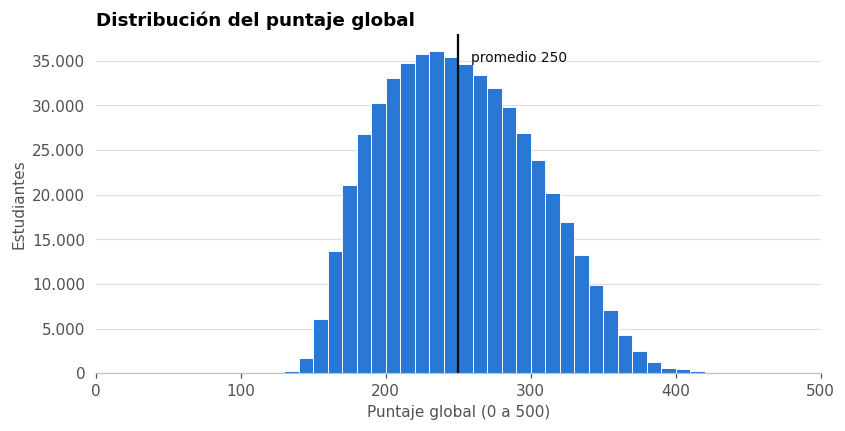

In [12]:
puntaje = pd.to_numeric(crudos[OBJETIVO], errors="coerce")
print(f"Puntajes válidos: {fmt(puntaje.notna().sum())} · faltantes: {fmt(puntaje.isna().sum())}")
print(f"Promedio {fmt(puntaje.mean(), 1)} · mediana {fmt(puntaje.median())} · desviación estándar {fmt(puntaje.std(), 1)}")
print(f"Mínimo {fmt(puntaje.min())} · máximo {fmt(puntaje.max())}")

fig, ax = plt.subplots()
ax.hist(puntaje.dropna(), bins=range(0, 505, 10), color=AZUL, edgecolor="white", linewidth=0.6)
ax.axvline(puntaje.mean(), color=TINTA, linewidth=1.5)
ax.annotate(f"promedio {fmt(puntaje.mean())}", xy=(puntaje.mean(), ax.get_ylim()[1] * 0.92),
            xytext=(8, 0), textcoords="offset points", color=TINTA, fontsize=9)
ax.set(title="Distribución del puntaje global", xlabel="Puntaje global (0 a 500)", ylabel="Estudiantes", xlim=(0, 500))
ax.yaxis.set_major_formatter(lambda y, _: fmt(y))
ax.grid(axis="x", visible=False)
plt.show()

La distribución tiene forma de campana y casi nadie llega a los extremos: la escala va de 0 a 500, pero los puntajes se concentran en un rango mucho más estrecho.

Ahora, el puntaje promedio según dos variables de contexto: el estrato y la educación de la madre. Cada barra muestra el promedio y, entre paréntesis, cuántos estudiantes hay en esa categoría.

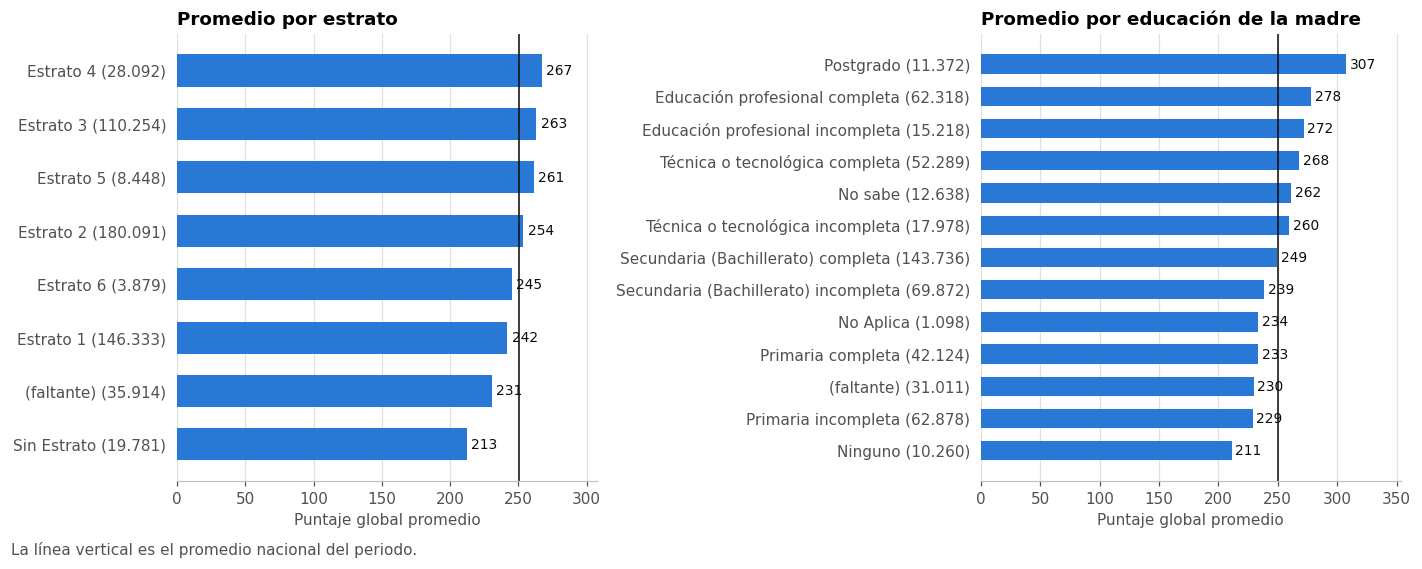

Educación de la madre: entre «Postgrado» y «Ninguno» hay 96 puntos de diferencia promedio.


In [13]:
def promedio_por(columna, ax, titulo):
    tabla = (pd.DataFrame({"categoria": crudos[columna].fillna("(faltante)"), "puntaje": puntaje})
             .dropna(subset=["puntaje"]).groupby("categoria")["puntaje"].agg(["mean", "size"])
             .sort_values("mean"))
    etiquetas = [f"{c} ({fmt(n)})" for c, n in zip(tabla.index, tabla["size"])]
    ax.barh(etiquetas, tabla["mean"], color=AZUL, height=0.6)
    for y, valor in enumerate(tabla["mean"]):
        ax.text(valor + 3, y, fmt(valor), va="center", fontsize=9, color=TINTA)
    ax.axvline(puntaje.mean(), color=TINTA, linewidth=1)
    ax.set(title=titulo, xlabel="Puntaje global promedio", xlim=(0, tabla["mean"].max() * 1.15))
    ax.grid(axis="y", visible=False)
    return tabla


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
por_estrato = promedio_por("fami_estratovivienda", ax1, "Promedio por estrato")
por_madre = promedio_por("fami_educacionmadre", ax2, "Promedio por educación de la madre")
fig.text(0.01, -0.02, "La línea vertical es el promedio nacional del periodo.", color=TINTA_2)
plt.tight_layout()
plt.show()

brecha = por_madre["mean"].max() - por_madre["mean"].min()
print(f"Educación de la madre: entre «{por_madre['mean'].idxmax()}» y «{por_madre['mean'].idxmin()}» "
      f"hay {fmt(brecha)} puntos de diferencia promedio.")

La educación de la madre muestra un gradiente muy claro: a más educación, mayor puntaje promedio. El estrato también se asocia con el puntaje, pero **mira con cuidado los estratos altos** y la categoría «Sin Estrato». Separemos por tipo de colegio:

In [14]:
por_tipo = (pd.DataFrame({"Estrato": crudos["fami_estratovivienda"], "Tipo de colegio": crudos["cole_naturaleza"], "puntaje": puntaje})
            .dropna().pivot_table(index="Estrato", columns="Tipo de colegio", values="puntaje", aggfunc=["mean", "size"]))
por_tipo.columns = [f"{'promedio' if a == 'mean' else 'estudiantes'} · {b}" for a, b in por_tipo.columns]
por_tipo.round(1)

,promedio · NO OFICIAL,promedio · OFICIAL,estudiantes · NO OFICIAL,estudiantes · OFICIAL
Estrato,,,,
Estrato 1,246.0,241.5,15402,130931
Estrato 2,266.1,250.7,35075,145016
Estrato 3,282.2,252.6,39524,70730
Estrato 4,297.4,233.4,14929,13163
Estrato 5,299.7,216.0,4581,3867
Estrato 6,295.8,204.4,1727,2152
Sin Estrato,229.2,210.8,1980,17801


En los colegios **no oficiales** el puntaje sube con el estrato, como uno esperaría. En los **oficiales**, en cambio, quienes marcan los estratos más altos obtienen en promedio **menos** que los de estrato 1. El estrato es **autorreportado** al inscribirse al examen: es probable que haya errores de reporte o que ese grupo sea muy particular.

Dos lecciones para el resto del cuaderno:
1. Los datos de encuesta tienen ruido; hay que mirarlos antes de confiar en ellos.
2. Estas diferencias son **correlaciones**: el estrato no "causa" el puntaje; resume condiciones del hogar y del colegio que sí se relacionan con él.

Una mirada rápida al tipo de colegio y a la zona:

In [15]:
tabla = (pd.DataFrame({"Tipo de colegio": crudos["cole_naturaleza"], "Zona": crudos["cole_area_ubicacion"], "puntaje": puntaje})
         .pivot_table(index="Tipo de colegio", columns="Zona", values="puntaje", aggfunc="mean"))
tabla.round(1)

Zona,RURAL,URBANO
Tipo de colegio,,
NO OFICIAL,291.1,271.7
OFICIAL,224.5,248.6


## 4. Limpieza

**Qué hacemos.**
1. Pasamos `punt_global` a número (`errors="coerce"` convierte lo que no sea número en faltante).
2. Quitamos las filas **sin objetivo** (no hay nada que aprender de ellas) y las que estén fuera de 0 a 500.
3. Nos quedamos con los resultados publicados (`estu_estadoinvestigacion = PUBLICAR`): los demás estaban bajo revisión.
4. En las variables categóricas, cambiamos los faltantes por la categoría **«Sin información»**.

**Por qué «Sin información» y no borrar filas ni rellenar con la moda.** Borrar filas con algún faltante bota muchos estudiantes y sesga la muestra: quienes no responden no son un grupo al azar. Rellenar con la moda inventa datos. Una categoría propia es honesta y deja que el modelo aprenda si "no responder" se asocia con el puntaje.

La otra parte de la limpieza, **agrupar las categorías con muy pocos casos**, depende de contar estudiantes; por eso se aprende en la sección 5, solo con el entrenamiento.

> **Error común que evitamos:** limpiar "a ojo" en celdas sueltas. Todo queda en una función que se aplica igual hoy, en el re-entrenamiento y en `train.py`.

La función `clave()` normaliza textos para compararlos sin tildes ni mayúsculas (así `BOGOTÁ` y `Bogota` son lo mismo).

In [16]:
def clave(texto: str) -> str:
    """Normaliza un texto para compararlo: sin tildes, mayúsculas y espacios simples."""
    sin_tildes = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode()
    return " ".join(sin_tildes.upper().split())


def limpiar(datos: pd.DataFrame, variables: list[str]) -> pd.DataFrame:
    datos = datos.copy()
    datos[OBJETIVO] = pd.to_numeric(datos[OBJETIVO], errors="coerce")
    datos = datos[datos[OBJETIVO].between(0, 500)]  # también descarta los NaN
    if "estu_estadoinvestigacion" in datos.columns:
        # Solo resultados publicados (quita los que estaban bajo investigación).
        estado = datos["estu_estadoinvestigacion"].fillna("").map(clave)
        if (estado == "PUBLICAR").any():
            datos = datos[estado == "PUBLICAR"]
    for columna in variables:
        texto = datos[columna].fillna("").astype(str).str.strip()
        datos[columna] = texto.replace("", SIN_INFO)
    return datos.reset_index(drop=True)

In [17]:
print("Estados de investigación:", crudos["estu_estadoinvestigacion"].value_counts(dropna=False).to_dict())

datos = limpiar(crudos, CANDIDATAS)
print(f"Estudiantes antes de limpiar: {fmt(len(crudos))}")
print(f"Estudiantes limpios:          {fmt(len(datos))} (se quitaron {fmt(len(crudos) - len(datos))})")
promedio_nacional = float(datos[OBJETIVO].mean())
print(f"Promedio nacional del periodo (datos limpios): {fmt(promedio_nacional, 1)}")
(datos[CANDIDATAS] == SIN_INFO).sum().rename("estudiantes con «Sin información»").to_frame()

Estados de investigación: {'PUBLICAR': 532566, 'VALIDEZ OFICINA JURÍDICA': 226}


Estudiantes antes de limpiar: 532.792
Estudiantes limpios:          532.566 (se quitaron 226)
Promedio nacional del periodo (datos limpios): 250,1


,estudiantes con «Sin información»
fami_estratovivienda,35897
fami_educacionmadre,30999
fami_educacionpadre,30891
fami_tieneinternet,31643
fami_tienecomputador,23551
fami_tieneautomovil,24567
cole_naturaleza,1
cole_jornada,1
cole_area_ubicacion,1
cole_bilingue,96033


## 5. Separación en entrenamiento y prueba

**Qué hacemos.** Separamos los datos: el 80 % para entrenar y el 20 % para evaluar. La semilla (`random_state`) hace que la separación sea la misma cada vez.

**Por qué ahora.** La separación va **antes de ajustar cualquier cosa**. Todo lo que el modelo aprende de los datos (qué categorías son raras, qué variables usar, qué columnas crea el codificador, los árboles) debe salir **solo** del entrenamiento. El set de prueba simula estudiantes que el modelo nunca vio.

> **Error común que evitamos: la fuga de información (*data leakage*).** Si decidimos qué categorías son "raras" contando en todos los datos, o si hacemos `pd.get_dummies` antes de separar, el set de prueba ya influyó en el modelo y la evaluación sale optimista.

Después de separar, agrupamos las categorías con **muy pocos casos**: las que tienen menos de `MIN_CASOS` estudiantes **en el entrenamiento** pasan a «Otra (pocos casos)». ¿Por qué 200? El promedio de un grupo de *n* estudiantes tiene un error típico de σ/√*n*: con 200 estudiantes ya es de unos 4 puntos, y con menos crece rápido. La regla aprendida en train se aplica igual al test. Esas categorías siguen en el modelo, pero la página no las ofrece como respuesta.

In [18]:
def aprender_frecuentes(train: pd.DataFrame, variables: list[str], min_casos: int) -> dict:
    frecuentes = {}
    for columna in variables:
        conteo = train[columna].value_counts()
        frecuentes[columna] = set(conteo[conteo >= min_casos].index)
    return frecuentes


def agrupar_raras(datos: pd.DataFrame, frecuentes: dict) -> pd.DataFrame:
    datos = datos.copy()
    for columna, conservar in frecuentes.items():
        datos[columna] = datos[columna].where(datos[columna].isin(conservar), OTRA)
    return datos

In [19]:
x = datos[CANDIDATAS]
y = datos[OBJETIVO]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=PROPORCION_PRUEBA, random_state=SEMILLA)

frecuentes = aprender_frecuentes(x_train, CANDIDATAS, MIN_CASOS)   # se aprende SOLO con train
raras = {v: sorted(set(x_train[v]) - frecuentes[v]) for v in CANDIDATAS}
raras = {v: r for v, r in raras.items() if r}
x_train = agrupar_raras(x_train, frecuentes)
x_test = agrupar_raras(x_test, frecuentes)                         # misma regla para test

print(f"Entrenamiento: {fmt(len(x_train))} estudiantes · Prueba: {fmt(len(x_test))} estudiantes")
print(f"Error típico del promedio de {MIN_CASOS} estudiantes: {fmt(y_train.std() / math.sqrt(MIN_CASOS), 1)} puntos")
print(f"Categorías agrupadas (menos de {MIN_CASOS} casos en train):", raras or "ninguna")

Entrenamiento: 426.052 estudiantes · Prueba: 106.514 estudiantes
Error típico del promedio de 200 estudiantes: 3,7 puntos
Categorías agrupadas (menos de 200 casos en train): {'cole_naturaleza': ['Sin información'], 'cole_jornada': ['Sin información'], 'cole_area_ubicacion': ['Sin información'], 'cole_depto_ubicacion': ['Sin información']}


## 6. Pipeline y cuatro modelos

**Qué hacemos.** Armamos un `Pipeline` de scikit-learn con dos pasos:

1. **`OneHotEncoder(handle_unknown="ignore")`** convierte cada categoría en una columna de ceros y unos. Por ejemplo, `fami_estratovivienda = "Estrato 3"` se vuelve un 1 en la columna *Estrato 3* y 0 en las demás. Con `handle_unknown="ignore"`, una categoría que no apareció en el entrenamiento queda en ceros. La página hace exactamente lo mismo.
2. **Un modelo.** Comparamos cuatro, de menos a más flexible:

| Modelo | Cómo decide, en una frase |
|---|---|
| Regresión lineal (`Ridge`) | Una suma: cada respuesta tiene un puntaje fijo que suma o resta. |
| Árbol de decisión | Un diagrama de preguntas de sí o no («¿la jornada es sabatina?») que termina en una hoja con un puntaje. |
| Bosque aleatorio | 50 árboles distintos, cada uno entrenado con una muestra al azar; la estimación es el promedio de todos. |
| **Gradient Boosting** | 100 árboles pequeños en fila: el primero hace una estimación gruesa y cada árbol nuevo corrige un poco el error que dejaron los anteriores. |

**Por qué árboles.** Una suma no puede representar **combinaciones**, por ejemplo que la jornada pese distinto en un colegio oficial que en uno privado. Un árbol sí, porque cada pregunta depende de las respuestas anteriores. El Gradient Boosting (`HistGradientBoostingRegressor`) suele ser el más preciso en datos de tablas como estos. (Para la lineal usamos `Ridge`, una regresión lineal con una penalización pequeña: con one-hot completo, `LinearRegression` no tiene una solución única.)

**Por qué igual se puede publicar sin servidor.** Un árbol es una lista de preguntas de sí o no, cada una con un umbral, y de hojas con un número. Exportamos todos esos números a `modelo.js` y la página recorre los árboles en el navegador (sección 9).

> **Error común que evitamos:** codificar a mano o con `pd.get_dummies` por separado en train y test. Las columnas pueden no coincidir y, en producción, una categoría nueva rompe todo. El pipeline guarda el codificador junto con el modelo.

Primero definimos los modelos. Con el Gradient Boosting elegimos las variables (validando dentro de train) y al final entrenamos el modelo definitivo.

In [20]:
# Los modelos que se comparan. Todos reciben las mismas columnas one-hot; el que
# se publica en la página es el Gradient Boosting.
MODELOS = {
    "lineal": "Regresión lineal (Ridge)",
    "arbol": "Árbol de decisión (profundidad 8)",
    "bosque": "Bosque aleatorio (50 árboles)",
    "boosting": "Gradient Boosting (100 árboles)",
}
PUBLICADO = "boosting"


def crear_modelo(variables: list[str], tipo: str = PUBLICADO) -> Pipeline:
    """Un Pipeline: one-hot de las categorías y después el modelo elegido."""
    regresores = {
        "lineal": Ridge(alpha=ALPHA),
        "arbol": DecisionTreeRegressor(max_depth=8, min_samples_leaf=100, random_state=SEMILLA),
        "bosque": RandomForestRegressor(n_estimators=50, max_depth=10, min_samples_leaf=100,
                                        max_features=0.5, n_jobs=-1, random_state=SEMILLA),
        # Los valores por defecto de scikit-learn: 100 árboles de hasta 31 hojas.
        "boosting": HistGradientBoostingRegressor(random_state=SEMILLA),
    }
    # El Gradient Boosting necesita una matriz densa; a la regresión lineal le basta una dispersa.
    codificador = OneHotEncoder(handle_unknown="ignore", sparse_output=tipo == "lineal")
    return Pipeline([
        ("preprocesamiento", ColumnTransformer([("categoricas", codificador, variables)])),
        ("regresion", regresores[tipo]),
    ])

### Qué variables usamos (validación dentro de train)

El formulario de la página debe tener entre 8 y 10 campos y partimos de 11 candidatas. Usamos tres criterios:

- **Calidad:** pocos faltantes y categorías con suficientes estudiantes (tabla de la sección 3).
- **Información nueva:** una variable que casi repite a otras suma poco y alarga el formulario.
- **Claridad para quien llena el formulario:** debe poder responderse sin buscar documentos.

Para medir la "información nueva" sin tocar el set de prueba, separamos **una parte del entrenamiento como validación**. Entrenamos el Gradient Boosting con las 11 variables y luego quitamos una a la vez (son 12 entrenamientos: tarda uno o dos minutos): si el error casi no cambia, esa variable no aporta información que las demás no tengan.

> **Error común que evitamos:** elegir variables mirando el desempeño en el set de prueba. Si probamos combinaciones hasta que el test mejore, el test deja de ser una evaluación honesta.

In [21]:
x_ajuste, x_valid, y_ajuste, y_valid = train_test_split(x_train, y_train, test_size=0.25, random_state=SEMILLA)


def validar(variables):
    m = crear_modelo(variables).fit(x_ajuste, y_ajuste)
    p = m.predict(x_valid)
    return r2_score(y_valid, p), mean_absolute_error(y_valid, p)


r2_todas, mae_todas = validar(CANDIDATAS)
filas = []
for variable in CANDIDATAS:
    r2, mae_v = validar([v for v in CANDIDATAS if v != variable])
    filas.append({"variable": variable, "% faltantes": round(100 * (x_train[variable] == SIN_INFO).mean(), 1),
                  "R² sin ella": round(r2, 4), "pérdida de R²": round(r2_todas - r2, 4),
                  "aumento del MAE (puntos)": round(mae_v - mae_todas, 3)})
print(f"Con las 11 variables, en validación: R² {fmt(r2_todas, 3)} · MAE {fmt(mae_todas, 2)}")
pd.DataFrame(filas).sort_values("pérdida de R²").set_index("variable")

Con las 11 variables, en validación: R² 0,325 · MAE 34,60


,% faltantes,R² sin ella,pérdida de R²,aumento del MAE (puntos)
variable,,,,
fami_tieneautomovil,4.6,0.3237,0.0013,0.037
cole_bilingue,18.0,0.3229,0.0022,0.046
fami_tieneinternet,5.9,0.3219,0.0031,0.100
fami_tienecomputador,4.4,0.3195,0.0055,0.147
cole_area_ubicacion,0.0,0.3182,0.0069,0.189
cole_naturaleza,0.0,0.3176,0.0075,0.197
fami_educacionpadre,5.8,0.3166,0.0084,0.238
fami_estratovivienda,6.8,0.3164,0.0086,0.247
fami_educacionmadre,5.8,0.3111,0.0139,0.395


Las dos variables que menos aportan están arriba de la tabla. Quitamos:

- **`fami_tieneautomovil`**: sin ella, el error de validación casi no cambia. Su información ya la traen el estrato, el computador y el internet.
- **`cole_bilingue`**: tiene la peor calidad (casi uno de cada cinco estudiantes sin dato y muy pocos colegios bilingües) y su aporte es mínimo.

Quedan **9 preguntas**, dentro del rango de 8 a 10. Las más importantes resultan ser la **jornada** (la sabatina y la nocturna suelen ser educación para adultos) y el **departamento**.

In [22]:
VARIABLES = ['fami_estratovivienda', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_tieneinternet', 'fami_tienecomputador', 'cole_naturaleza', 'cole_jornada', 'cole_area_ubicacion', 'cole_depto_ubicacion']
MOTIVOS_FUERA = {'fami_tieneautomovil': 'Casi no aporta en validación: su información ya la traen el estrato, el computador y el internet.', 'cole_bilingue': 'La peor calidad de datos (18 % de faltantes) y un aporte mínimo en validación.'}

r2_final, mae_final = validar(VARIABLES)
print(f"{len(VARIABLES)} variables en el modelo: {', '.join(VARIABLES)}")
print(f"Fuera del modelo: {[v for v in CANDIDATAS if v not in VARIABLES]}")
print(f"Validación con las {len(VARIABLES)}: R² {fmt(r2_final, 3)} · MAE {fmt(mae_final, 2)} "
      f"(con las 11: R² {fmt(r2_todas, 3)} · MAE {fmt(mae_todas, 2)})")

9 variables en el modelo: fami_estratovivienda, fami_educacionmadre, fami_educacionpadre, fami_tieneinternet, fami_tienecomputador, cole_naturaleza, cole_jornada, cole_area_ubicacion, cole_depto_ubicacion
Fuera del modelo: ['fami_tieneautomovil', 'cole_bilingue']
Validación con las 9: R² 0,322 · MAE 34,69 (con las 11: R² 0,325 · MAE 34,60)


### ¿Qué modelo publicamos? (también en validación)

Con las 9 variables comparamos los cuatro modelos **en la misma validación**, sin tocar el set de prueba. Así la elección del modelo tampoco se hace mirando la prueba.

In [23]:
filas = []
for tipo, nombre in MODELOS.items():
    p = crear_modelo(VARIABLES, tipo).fit(x_ajuste, y_ajuste).predict(x_valid)
    filas.append({"modelo": nombre, "MAE en validación": round(mean_absolute_error(y_valid, p), 2),
                  "R² en validación": round(r2_score(y_valid, p), 3)})
pd.DataFrame(filas).set_index("modelo")

,MAE en validación,R² en validación
modelo,,
Regresión lineal (Ridge),35.43,0.295
Árbol de decisión (profundidad 8),36.56,0.252
Bosque aleatorio (50 árboles),35.96,0.279
Gradient Boosting (100 árboles),34.69,0.322


El Gradient Boosting es el que menos se equivoca en validación. Es el que publicamos.

### Modelo final

Entrenamos el Gradient Boosting con las variables elegidas y **todo** el set de entrenamiento. Usamos los valores por defecto de scikit-learn: 100 árboles de hasta 31 hojas y una tasa de aprendizaje de 0,1 (cuánto corrige cada árbol nuevo).

In [24]:
modelo = crear_modelo(VARIABLES).fit(x_train, y_train)
codificador = modelo.named_steps["preprocesamiento"].named_transformers_["categoricas"]
boosting = modelo.named_steps["regresion"]
print(f"Columnas después del one-hot: {len(codificador.get_feature_names_out())}")
print(f"Árboles: {boosting.n_iter_} · hojas por árbol: hasta {boosting.max_leaf_nodes} · "
      f"tasa de aprendizaje: {fmt(boosting.learning_rate, 1)}")
modelo

Columnas después del one-hot: 87
Árboles: 100 · hojas por árbol: hasta 31 · tasa de aprendizaje: 0,1


Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['fami_estratovivienda',
                                                   'fami_educacionmadre',
                                                   'fami_educacionpadre',
                                                   'fami_tieneinternet',
                                                   'fami_tienecomputador',
                                                   'cole_naturaleza',
                                                   'cole_jornada',
                                                   'cole_area_ubicacion',
                                                   'cole_depto_ubicacion'])])),
                ('regresion', HistGradientBoostingRegressor(random_state=42))])

## 7. Comparación de modelos contra una línea base

**Qué hacemos.** Entrenamos los cuatro modelos con todo el entrenamiento y medimos su error en el set de prueba, el mismo para todos, con tres métricas:

- **MAE** (error absoluto medio): en promedio, ¿por cuántos puntos se equivoca? Es la más fácil de explicar.
- **RMSE** (raíz del error cuadrático medio): parecida, pero castiga más los errores grandes.
- **R²**: qué parte de la variación del puntaje explica el modelo. 0 equivale a responder siempre el promedio; 1 sería perfecto.

Y los comparamos con una **línea base**: un `DummyRegressor` que siempre responde el promedio del entrenamiento.

**Por qué una línea base.** Un MAE de 35 puntos no dice nada solo. ¿Es bueno? Depende de cuánto se equivoca "no saber nada". Un modelo vale la pena en la medida en que le gana a esa referencia.

> **Error común que evitamos:** reportar métricas sin línea base, medir en los mismos datos con los que se entrenó, o probar modelos en el set de prueba hasta que uno "gane". El modelo ya lo elegimos en validación; la prueba solo confirma.

In [25]:
def metricas(y_real, y_pred) -> dict:
    return {
        "mae": float(mean_absolute_error(y_real, y_pred)),
        "rmse": float(math.sqrt(mean_squared_error(y_real, y_pred))),
        "r2": float(r2_score(y_real, y_pred)),
    }

In [26]:
base = DummyRegressor(strategy="mean").fit(x_train, y_train)
comparacion = [{"clave": "linea_base", "nombre": "Línea base: siempre el promedio",
                **metricas(y_test, base.predict(x_test))}]
modelos = {PUBLICADO: modelo}
for tipo in MODELOS:
    if tipo not in modelos:
        modelos[tipo] = crear_modelo(VARIABLES, tipo).fit(x_train, y_train)
    nombre = MODELOS[tipo]
    if tipo == "boosting":  # con parada temprana podría usar menos de 100 árboles
        nombre = f"Gradient Boosting ({modelos[tipo].named_steps['regresion'].n_iter_} árboles)"
    fila = {"clave": tipo, "nombre": nombre, **metricas(y_test, modelos[tipo].predict(x_test))}
    if tipo == PUBLICADO:
        fila["publicado"] = True
    comparacion.append(fila)
resultados = {"modelo": next(f for f in comparacion if f.get("publicado")),
              "linea_base": comparacion[0], "comparacion": comparacion}
display(pd.DataFrame(comparacion).set_index("nombre")[["mae", "rmse", "r2"]].round(3))

pred_modelo = modelo.predict(x_test)
mae = resultados["modelo"]["mae"]
mejora = 1 - mae / resultados["linea_base"]["mae"]
cobertura = float(np.mean(np.abs(y_test.to_numpy() - pred_modelo) <= mae))
lineal = next(f for f in comparacion if f["clave"] == "lineal")
print(f"El Gradient Boosting se equivoca en promedio {fmt(mae, 1)} puntos; la línea base, "
      f"{fmt(resultados['linea_base']['mae'], 1)}. Mejora del {fmt(100 * mejora)} %.")
print(f"La regresión lineal se equivoca {fmt(lineal['mae'], 1)} puntos: el boosting le gana por {fmt(lineal['mae'] - mae, 1)}.")
print(f"R² = {fmt(resultados['modelo']['r2'], 3)}: el contexto explica cerca del "
      f"{fmt(100 * resultados['modelo']['r2'])} % de la variación del puntaje.")
print(f"En el {fmt(100 * cobertura)} % de los estudiantes de prueba, el puntaje real quedó dentro de ± MAE.")

,mae,rmse,r2
nombre,,,
Línea base: siempre el promedio,42.936,51.796,-0.000
Regresión lineal (Ridge),35.475,43.675,0.289
Árbol de decisión (profundidad 8),36.534,44.888,0.249
Bosque aleatorio (50 árboles),35.945,44.122,0.274
Gradient Boosting (100 árboles),34.725,42.831,0.316


El Gradient Boosting se equivoca en promedio 34,7 puntos; la línea base, 42,9. Mejora del 19 %.
La regresión lineal se equivoca 35,5 puntos: el boosting le gana por 0,8.
R² = 0,316: el contexto explica cerca del 32 % de la variación del puntaje.
En el 56 % de los estudiantes de prueba, el puntaje real quedó dentro de ± MAE.


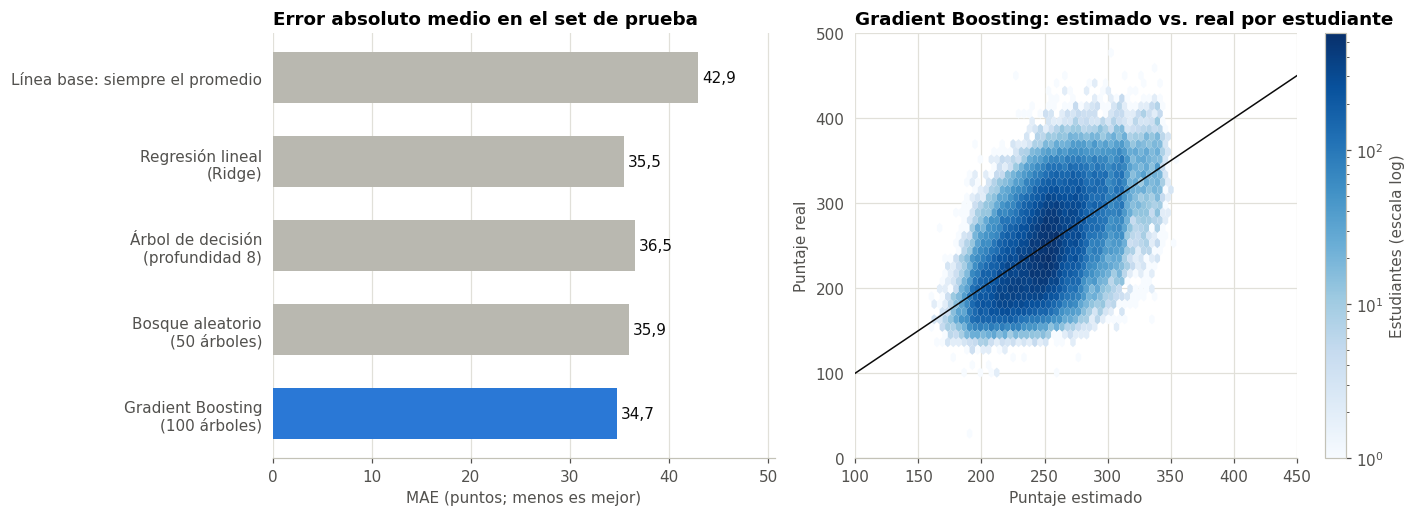

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1, 1.1]})
nombres = [f["nombre"].replace(" (", "\n(") for f in comparacion]
valores = [f["mae"] for f in comparacion]
ax1.barh(nombres, valores, color=[AZUL if f.get("publicado") else GRIS for f in comparacion], height=0.6)
for y_pos, valor in enumerate(valores):
    ax1.text(valor + 0.4, y_pos, fmt(valor, 1), va="center", color=TINTA)
ax1.invert_yaxis()
ax1.set(title="Error absoluto medio en el set de prueba", xlabel="MAE (puntos; menos es mejor)",
        xlim=(0, max(valores) * 1.18))
ax1.grid(axis="y", visible=False)

hb = ax2.hexbin(pred_modelo, y_test, gridsize=45, cmap="Blues", mincnt=1, bins="log", linewidths=0)
ax2.plot([0, 500], [0, 500], color=TINTA, linewidth=1)
ax2.set(title="Gradient Boosting: estimado vs. real por estudiante", xlabel="Puntaje estimado",
        ylabel="Puntaje real", xlim=(100, 450), ylim=(0, 500))
fig.colorbar(hb, ax=ax2, label="Estudiantes (escala log)")
plt.tight_layout()
plt.show()

**Cómo leer la gráfica de la derecha.** Si el modelo fuera perfecto, todos los puntos estarían sobre la diagonal. En cambio, para un mismo puntaje estimado hay estudiantes reales muy por encima y muy por debajo. Esa es la razón técnica detrás del aviso ético: el modelo describe **promedios de grupos**, no personas.

**Por qué el boosting gana, pero por poco.** Con 9 preguntas sobre el contexto, la información tiene un techo: ningún modelo puede adivinar lo que no está en los datos (el esfuerzo, el colegio concreto, cómo le fue a cada quien ese día). Un modelo más flexible exprime un poco más la misma información, pero no hace magia. Un solo árbol, en cambio, se equivoca más que la regresión lineal: es demasiado simple para tantas combinaciones.

## 8. Qué aprendió el Gradient Boosting

**Qué hacemos.** Un modelo de 100 árboles no tiene coeficientes que se lean de un vistazo. Usamos tres herramientas para entenderlo:

1. **Cómo decide un árbol:** recorremos el primer árbol con las respuestas del estudiante típico.
2. **Qué pesa más:** cuánto mueve cada pregunta la estimación, en promedio.
3. **Qué pasa al cambiar una respuesta, dejando lo demás igual** (dependencia parcial).

> **Errores comunes que evitamos:**
> 1. Tratar el modelo como una caja negra "porque es complejo". Siempre se le puede preguntar qué hace.
> 2. Leer la importancia como causa. Que el computador "pese" mucho no significa que comprar uno suba el puntaje: describe a estudiantes distintos.

Primero, las funciones que convierten los árboles en listas de números y los recorren. Son las mismas de la exportación (sección 9) y hacen la misma cuenta que la página.

In [28]:
def arboles_de(regresor) -> dict:
    """Los árboles de un modelo de scikit-learn como listas de números (lo que lee web/motor.js).

    Por cada nodo: la columna por la que pregunta (c; -1 en las hojas), el umbral (u),
    el hijo si columna <= umbral (i), el hijo si no (d) y el valor del nodo (v).
    estimación = base + escala x (suma de las hojas a las que llega cada árbol).
    modo: "suma" (Gradient Boosting), "promedio" (bosque aleatorio) o "arbol" (uno solo).
    """
    def entero(a):
        return np.asarray(a).astype(np.int64)  # algunos índices vienen sin signo (uint32)

    def arbol(columna, umbral, izquierda, derecha, valor):
        hoja = entero(izquierda) < 0
        return {"c": np.where(hoja, -1, entero(columna)).tolist(),
                "u": np.where(hoja, 0.0, np.asarray(umbral, dtype=float)).tolist(),
                "i": np.where(hoja, -1, entero(izquierda)).tolist(),
                "d": np.where(hoja, -1, entero(derecha)).tolist(),
                "v": np.asarray(valor, dtype=float).tolist()}

    if isinstance(regresor, HistGradientBoostingRegressor):
        # scikit-learn guarda estos árboles en _predictors, un atributo interno. Si una
        # versión futura lo cambia, este paso falla (o falla la prueba de paridad).
        lista = []
        for (predictor,) in regresor._predictors:
            nodos = predictor.nodes
            if nodos["is_categorical"].any():
                raise ValueError("Se esperaban solo columnas numéricas o one-hot")
            hoja = nodos["is_leaf"].astype(bool)
            izquierda = np.where(hoja, -1, entero(nodos["left"]))
            derecha = np.where(hoja, -1, entero(nodos["right"]))
            # Las hojas ya traen la tasa de aprendizaje. Cada nodo interno recibe el promedio
            # de sus dos hijos, ponderado por casos: con eso se reparten los aportes.
            valor = nodos["value"].astype(float)
            for n in range(len(nodos) - 1, -1, -1):
                if not hoja[n]:
                    i, d = izquierda[n], derecha[n]
                    if min(i, d) <= n:
                        raise ValueError("Orden de nodos inesperado en el árbol")
                    casos_i, casos_d = float(nodos["count"][i]), float(nodos["count"][d])
                    valor[n] = (casos_i * valor[i] + casos_d * valor[d]) / (casos_i + casos_d)
            lista.append(arbol(nodos["feature_idx"], nodos["num_threshold"], izquierda, derecha, valor))
        return {"modo": "suma", "base": float(np.ravel(regresor._baseline_prediction)[0]),
                "escala": 1.0, "float32": False, "lista": lista}
    if isinstance(regresor, RandomForestRegressor):
        arboles, escala, modo = [e.tree_ for e in regresor.estimators_], 1.0 / len(regresor.estimators_), "promedio"
    elif isinstance(regresor, DecisionTreeRegressor):
        arboles, escala, modo = [regresor.tree_], 1.0, "arbol"
    else:
        raise TypeError(f"No sé exportar {type(regresor).__name__}")
    # Estos árboles de scikit-learn comparan en float32; motor.js hace lo mismo.
    return {"modo": modo, "base": 0.0, "escala": escala, "float32": True,
            "lista": [arbol(a.feature, a.threshold, a.children_left, a.children_right, a.value[:, 0, 0])
                      for a in arboles]}


def recorrer_arboles(arboles: dict, x, variable_de_columna, n_variables: int):
    """Hace en Python lo mismo que web/motor.js, para muchas filas a la vez.

    Devuelve la estimación, el punto de partida y el aporte de cada variable: cuánto
    cambió el valor del nodo en los pasos del camino que preguntaron por ella.
    """
    x = np.asarray(x, dtype=float)
    if arboles["float32"]:
        x = x.astype(np.float32).astype(float)
    variable_de_columna = np.asarray(variable_de_columna)
    filas = np.arange(len(x))
    escala = arboles["escala"]
    estimacion = np.full(len(x), arboles["base"])
    partida = arboles["base"]
    aportes = np.zeros((len(x), n_variables))
    for arbol in arboles["lista"]:
        c, u, i, d, v = (np.asarray(arbol[k]) for k in ("c", "u", "i", "d", "v"))
        partida += escala * v[0]
        nodo = np.zeros(len(x), dtype=int)
        activas = c[nodo] >= 0
        while activas.any():
            f, n = filas[activas], nodo[activas]
            hijo = np.where(x[f, c[n]] <= u[n], i[n], d[n])
            np.add.at(aportes, (f, variable_de_columna[c[n]]), escala * (v[hijo] - v[n]))
            nodo[f] = hijo
            activas = c[nodo] >= 0
        estimacion += escala * v[nodo]
    return estimacion, partida, aportes

In [29]:
arboles = arboles_de(boosting)
columnas_arbol = [[v, str(c)] for v, lista in zip(VARIABLES, codificador.categories_) for c in lista]
variable_de_columna = [VARIABLES.index(c[0]) for c in columnas_arbol]
print(f"{len(arboles['lista'])} árboles · {fmt(sum(len(a['v']) for a in arboles['lista']))} nodos en total · "
      f"punto de partida {fmt(arboles['base'], 2)} puntos")

# El estudiante típico: la respuesta más común en cada pregunta.
tipico = pd.DataFrame([{v: x_train[v].value_counts().idxmax() for v in VARIABLES}])
x_tipico = modelo.named_steps["preprocesamiento"].transform(tipico)
arbol, n = arboles["lista"][0], 0
print("\nEl árbol 1 con el estudiante típico:")
while arbol["c"][n] >= 0:
    variable, categoria = columnas_arbol[arbol["c"][n]]
    es = x_tipico[0, arbol["c"][n]] > arbol["u"][n]
    print(f"  ¿{variable} es «{categoria}»? {'Sí' if es else 'No'}")
    n = arbol["d"][n] if es else arbol["i"][n]
print(f"  Llega a una hoja que {'suma' if arbol['v'][n] >= 0 else 'resta'} {fmt(abs(arbol['v'][n]), 2)} puntos.")
estimacion, partida, aportes_tipico = recorrer_arboles(arboles, x_tipico, variable_de_columna, len(VARIABLES))
print(f"\nCon los {len(arboles['lista'])} árboles: punto de partida {fmt(partida, 1)} + aportes "
      f"{fmt(aportes_tipico.sum(), 1)} = {fmt(estimacion[0], 1)} (scikit-learn: {fmt(modelo.predict(tipico)[0], 1)})")

100 árboles · 6.100 nodos en total · punto de partida 250,18 puntos

El árbol 1 con el estudiante típico:
  ¿fami_tienecomputador es «Si»? Sí
  ¿cole_jornada es «COMPLETA»? No
  ¿cole_jornada es «SABATINA»? No
  ¿cole_jornada es «NOCHE»? No
  ¿fami_tieneinternet es «Si»? Sí
  ¿cole_naturaleza es «NO OFICIAL»? No
  ¿cole_area_ubicacion es «RURAL»? No
  ¿fami_educacionmadre es «Técnica o tecnológica completa»? No
  ¿fami_educacionmadre es «Educación profesional completa»? No
  ¿fami_educacionmadre es «Postgrado»? No
  ¿cole_depto_ubicacion es «SANTANDER»? No
  Llega a una hoja que suma 0,75 puntos.

Con los 100 árboles: punto de partida 250,2 + aportes 9,5 = 259,6 (scikit-learn: 259,6)


**Qué pesa más.** Para 5.000 estudiantes de entrenamiento medimos cuánto sube o baja la estimación por cada pregunta. Seguimos el camino de cada estudiante por los 100 árboles: el valor de cada nodo es el promedio de los estudiantes que llegan a él, y lo que cambia en cada paso se le atribuye a la pregunta de ese paso. Es la misma cuenta de la gráfica «Qué suma y qué resta» de la página.

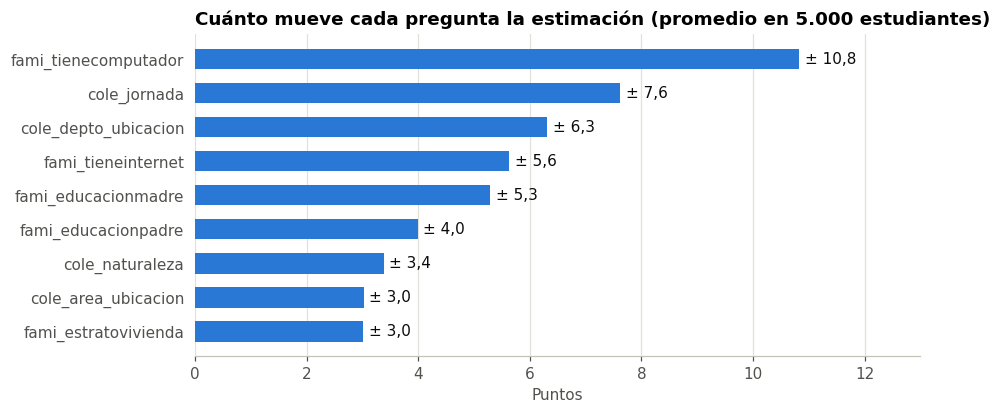

In [30]:
muestra_train = x_train.sample(n=5000, random_state=SEMILLA)
_, _, aportes = recorrer_arboles(arboles, modelo.named_steps["preprocesamiento"].transform(muestra_train),
                                 variable_de_columna, len(VARIABLES))
importancia = pd.Series(np.abs(aportes).mean(axis=0), index=VARIABLES).sort_values()
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.barh(importancia.index, importancia.values, color=AZUL, height=0.6)
for y_pos, valor in enumerate(importancia.values):
    ax.text(valor + 0.1, y_pos, f"± {fmt(valor, 1)}", va="center", color=TINTA)
ax.set(title="Cuánto mueve cada pregunta la estimación (promedio en 5.000 estudiantes)", xlabel="Puntos",
       xlim=(0, importancia.max() * 1.2))
ax.grid(axis="y", visible=False)
plt.show()

**Qué pasa al cambiar una respuesta (dependencia parcial).** Tomamos 3.000 estudiantes de entrenamiento y les ponemos **a todos** la misma respuesta en una pregunta, dejando sus demás respuestas como están. El promedio de las estimaciones dice cuánto «vale» esa respuesta en el modelo. Comparamos cada respuesta con la más frecuente de su pregunta (la referencia): *«pasar de X a Y suma o resta N puntos, dejando lo demás igual»*.

In [31]:
muestra_pd = x_train.sample(n=3000, random_state=SEMILLA)
filas = []
for variable in VARIABLES:
    conteo = x_train[variable].value_counts()
    referencia = conteo.idxmax()
    # Solo respuestas que aparecen en el formulario (al menos MIN_CASOS estudiantes en train).
    promedios = {c: modelo.predict(muestra_pd.assign(**{variable: c})).mean() for c in conteo[conteo >= MIN_CASOS].index}
    for categoria, promedio in promedios.items():
        filas.append({"variable": variable, "categoría": categoria, "vs. más frecuente": promedio - promedios[referencia],
                      "referencia": referencia, "estudiantes (train)": int(conteo[categoria])})
visibles = pd.DataFrame(filas)


def frase(puntos):
    return f"suma {fmt(puntos, 1)}" if puntos >= 0 else f"resta {fmt(-puntos, 1)}"


for variable, grupo in visibles.groupby("variable", sort=False):
    ref = grupo["referencia"].iloc[0]
    otras = grupo[grupo["categoría"] != ref]
    alta = otras.loc[otras["vs. más frecuente"].idxmax()]
    baja = otras.loc[otras["vs. más frecuente"].idxmin()]
    texto = f"{variable}: pasar de «{ref}» a «{alta['categoría']}» {frase(alta['vs. más frecuente'])} puntos"
    if baja["categoría"] != alta["categoría"]:
        texto += f"; a «{baja['categoría']}», {frase(baja['vs. más frecuente'])}"
    print(texto + ".")

fami_estratovivienda: pasar de «Estrato 2» a «Estrato 1» suma 0,4 puntos; a «Estrato 6», resta 20,3.
fami_educacionmadre: pasar de «Secundaria (Bachillerato) completa» a «Postgrado» suma 14,2 puntos; a «Ninguno», resta 17,2.
fami_educacionpadre: pasar de «Secundaria (Bachillerato) completa» a «Postgrado» suma 11,8 puntos; a «Ninguno», resta 17,5.
fami_tieneinternet: pasar de «Si» a «No» resta 10,5 puntos; a «Sin información», resta 12,9.
fami_tienecomputador: pasar de «Si» a «Sin información» resta 2,3 puntos; a «No», resta 10,2.
cole_naturaleza: pasar de «OFICIAL» a «NO OFICIAL» suma 9,3 puntos.
cole_jornada: pasar de «MAÑANA» a «COMPLETA» suma 7,6 puntos; a «SABATINA», resta 32,4.
cole_area_ubicacion: pasar de «URBANO» a «RURAL» resta 9,8 puntos.
cole_depto_ubicacion: pasar de «BOGOTÁ» a «SANTANDER» suma 10,8 puntos; a «CHOCO», resta 32,8.


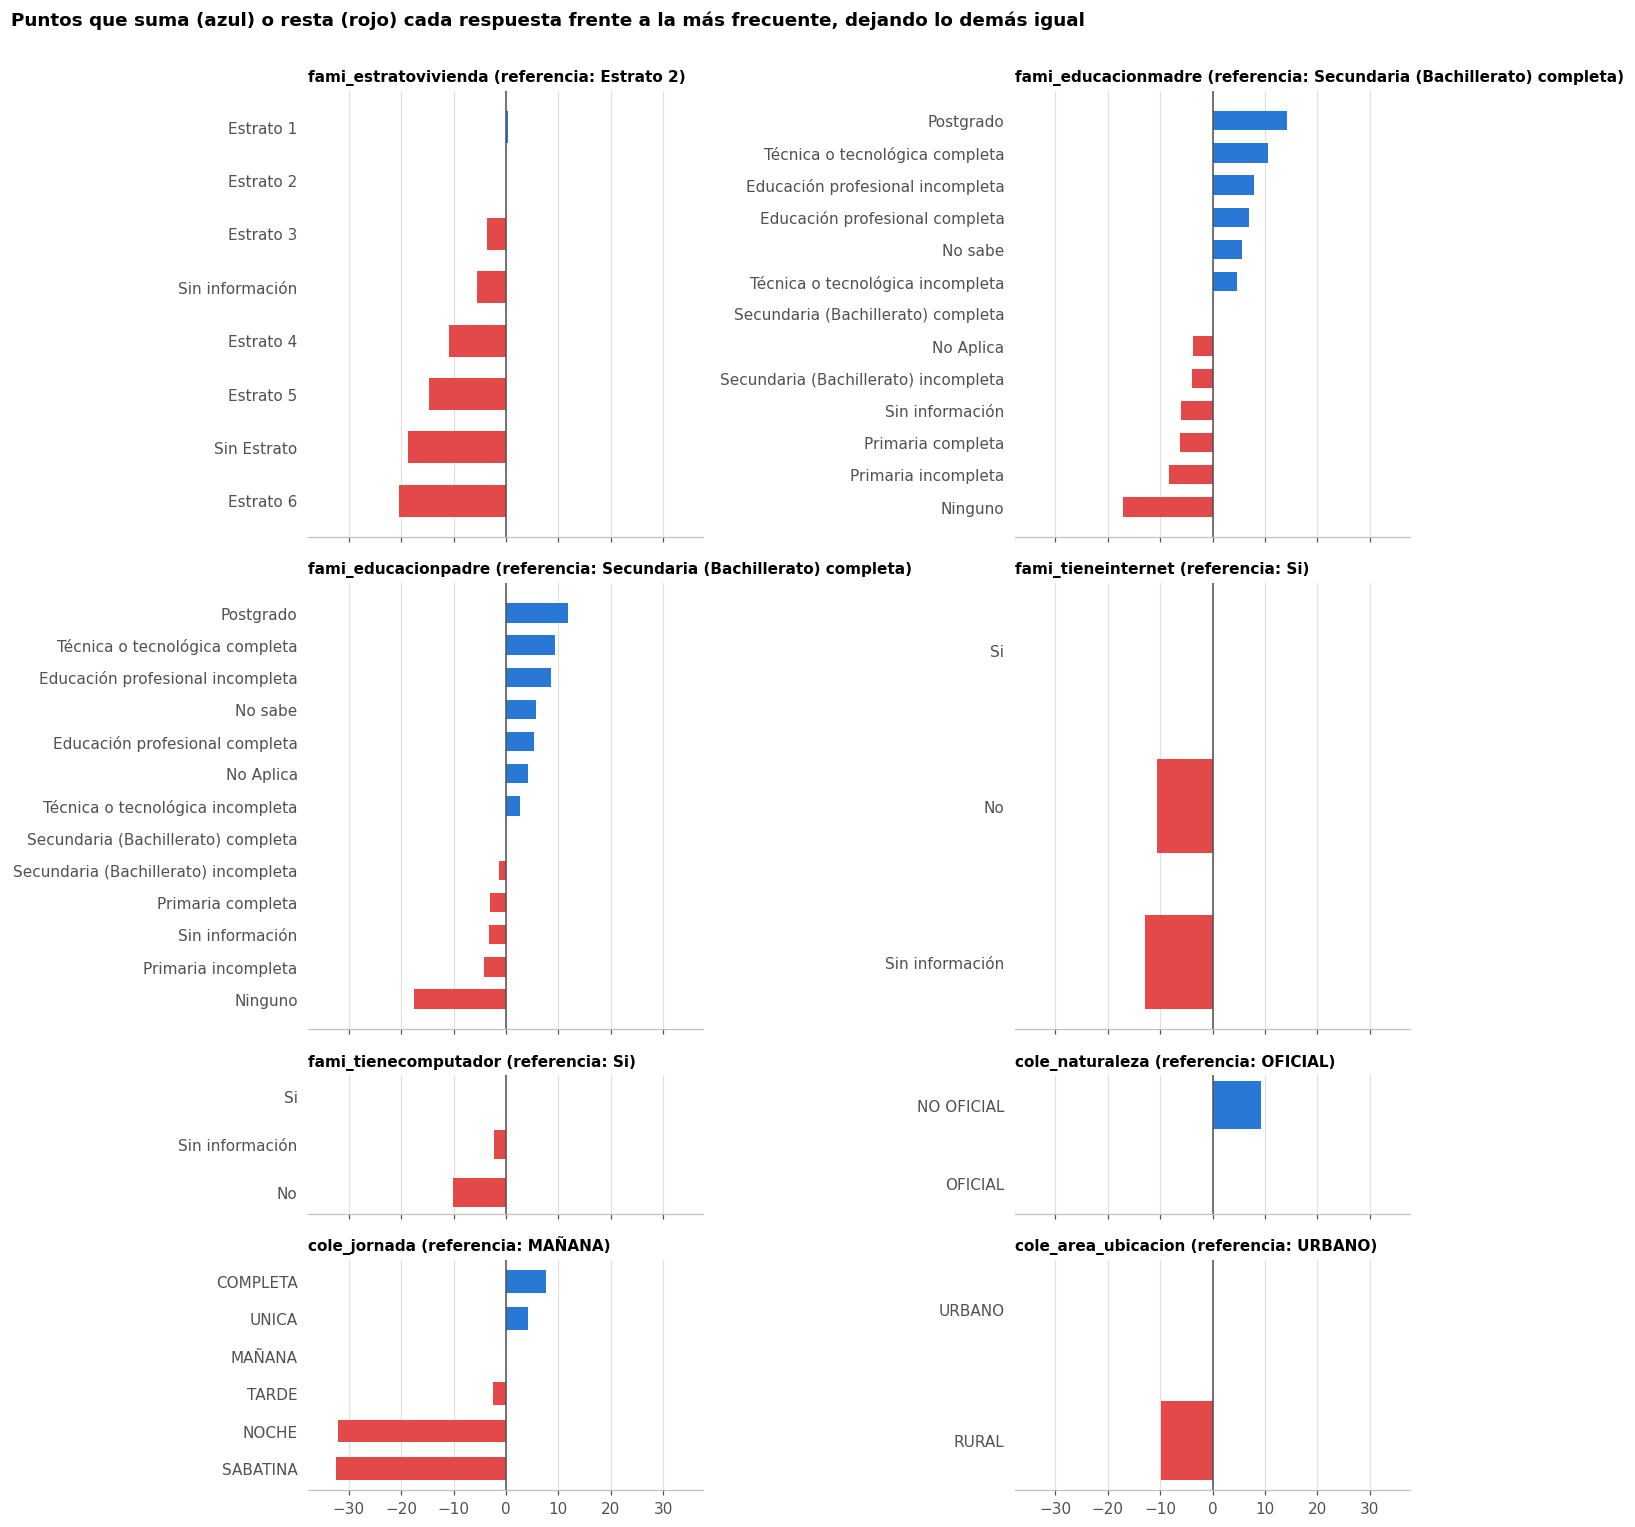

In [32]:
otras = [v for v in VARIABLES if v != "cole_depto_ubicacion"]
columnas_grafica = 2
filas_grafica = math.ceil(len(otras) / columnas_grafica)
alturas = [max(len(visibles[visibles.variable == v]) for v in otras[i:i + columnas_grafica]) + 1.5
           for i in range(0, len(otras), columnas_grafica)]
fig, ejes = plt.subplots(filas_grafica, columnas_grafica, figsize=(13, sum(alturas) * 0.32 + 1),
                         gridspec_kw={"height_ratios": alturas}, sharex=True)
limite = visibles["vs. más frecuente"].abs().max() * 1.15
for ax, variable in zip(ejes.flat, otras):
    grupo = visibles[visibles.variable == variable].sort_values("vs. más frecuente")
    colores = [GRIS if abs(d) < 1e-9 else (AZUL if d > 0 else ROJO) for d in grupo["vs. más frecuente"]]
    ax.barh(grupo["categoría"], grupo["vs. más frecuente"], color=colores, height=0.6)
    ax.axvline(0, color=TINTA_2, linewidth=1)
    ax.set_title(f"{variable} (referencia: {grupo['referencia'].iloc[0]})", fontsize=10)
    ax.set_xlim(-limite, limite)
    ax.grid(axis="y", visible=False)
for ax in list(ejes.flat)[len(otras):]:
    ax.set_visible(False)
fig.suptitle("Puntos que suma (azul) o resta (rojo) cada respuesta frente a la más frecuente, dejando lo demás igual", x=0.01, ha="left",
             fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.975))
plt.show()

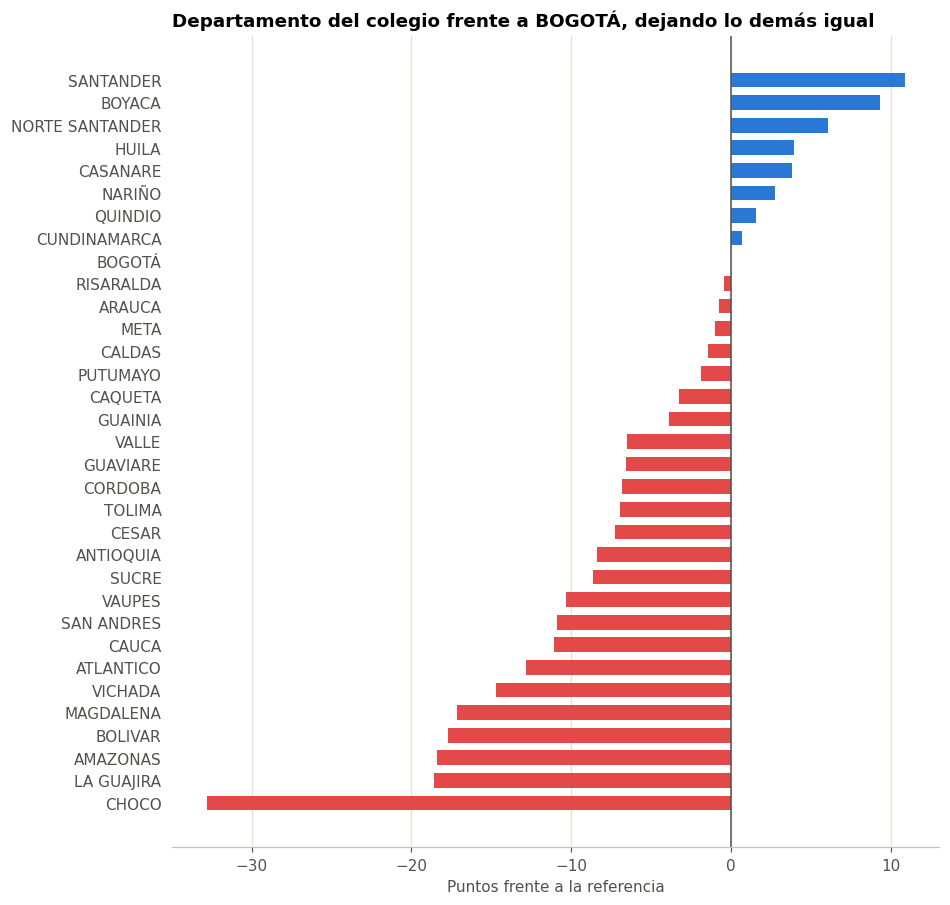

In [33]:
grupo = visibles[visibles.variable == "cole_depto_ubicacion"].sort_values("vs. más frecuente")
fig, ax = plt.subplots(figsize=(9, len(grupo) * 0.26 + 1))
colores = [GRIS if abs(d) < 1e-9 else (AZUL if d > 0 else ROJO) for d in grupo["vs. más frecuente"]]
ax.barh(grupo["categoría"], grupo["vs. más frecuente"], color=colores, height=0.65)
ax.axvline(0, color=TINTA_2, linewidth=1)
ax.set(title=f"Departamento del colegio frente a {grupo['referencia'].iloc[0]}, dejando lo demás igual",
       xlabel="Puntos frente a la referencia")
ax.grid(axis="y", visible=False)
plt.show()

### Brecha cruda frente a efecto ajustado

La dependencia parcial es un efecto **ajustado**: compara a los mismos estudiantes cambiando solo una respuesta. La brecha cruda de la sección 3 compara grupos que también difieren en todo lo demás. El estrato es el mejor ejemplo:

In [34]:
entrenamiento = x_train.assign(puntaje=y_train)
grupo_estrato = visibles[visibles.variable == "fami_estratovivienda"].set_index("categoría")
ref_estrato = grupo_estrato["referencia"].iloc[0]
crudo = entrenamiento.groupby("fami_estratovivienda")["puntaje"].mean()
pd.DataFrame({
    f"brecha cruda vs. {ref_estrato}": (crudo - crudo[ref_estrato]).reindex(grupo_estrato.index).round(1),
    f"efecto ajustado vs. {ref_estrato}": grupo_estrato["vs. más frecuente"].round(1),
    "estudiantes (train)": grupo_estrato["estudiantes (train)"],
})

,brecha cruda vs. Estrato 2,efecto ajustado vs. Estrato 2,estudiantes (train)
categoría,,,
Estrato 2,0.0,0.0,143652
Estrato 1,-11.6,0.4,117197
Estrato 3,9.6,-3.7,88286
Sin información,-23.1,-5.4,28800
Estrato 4,13.7,-10.9,22422
Sin Estrato,-41.1,-18.6,15752
Estrato 5,8.1,-14.7,6840
Estrato 6,-8.4,-20.3,3103


Una vez que el modelo conoce la educación de los padres, el internet, el computador, el tipo de colegio, la jornada, la zona y el departamento, **al estrato le queda poca información propia**, y en este periodo su efecto ajustado incluso se invierte en los estratos altos. Tiene sentido con lo que vimos en la sección 3: el estrato es autorreportado y, en los colegios oficiales, quienes marcan estratos altos obtuvieron menos. La regresión lineal encuentra lo mismo: no es un capricho del boosting.

**Para discutir.** ¿Significa esto que vivir en estrato 6 "baja" el puntaje? No. El efecto ajustado describe una situación hipotética (*todo lo demás igual*) que casi no existe en los datos: pocos estudiantes de estrato 6 estudian en jornada sabatina en un colegio oficial rural. Es un recordatorio de que un modelo con variables correlacionadas no se lee como una lista de causas.

## 9. Exportación a `modelo.js` y prueba de paridad

**Qué hacemos.** Guardamos el modelo como **números**: por cada uno de los 100 árboles, cada nodo con su pregunta (qué columna y qué umbral), sus dos hijos y su valor; y por cada variable, su lista de categorías con una etiqueta legible en español. Lo escribimos en dos archivos:

- `web/modelo.js` define `window.MODELO = {...}`. Funciona tanto al abrir `index.html` con doble clic como en GitHub Pages (un `fetch` de un `.json` fallaría al abrir el archivo directamente).
- `web/modelo.json`, el mismo contenido para quien quiera leerlo o usarlo desde otro programa.

**Por qué números y no un `.pkl`.** GitHub Pages solo publica archivos estáticos: no ejecuta Python ni ningún código en el servidor (Netlify tampoco: sus funciones solo corren JavaScript/TypeScript, y Go mediante la API compatible con Lambda). Un `.pkl` de scikit-learn no podría correr allí. Pero un árbol son preguntas de sí o no: basta con los números y unas pocas líneas de JavaScript que los recorren (`web/motor.js`).

Primero, las etiquetas legibles y el orden de las categorías para el formulario. Se escribieron a partir de los valores únicos reales de la sección 3; si un valor no tiene etiqueta, la exportación avisa.

In [35]:
# Nombre, etiqueta corta, grupo y ayuda de cada variable (para el formulario).
INFO_VARIABLES = {
    "fami_estratovivienda": ("Estrato de la vivienda", "Estrato", "hogar",
                             "Aparece en los recibos de servicios públicos."),
    "fami_educacionmadre": ("Nivel educativo de la madre", "Educación de la madre", "hogar",
                            "El nivel más alto que alcanzó."),
    "fami_educacionpadre": ("Nivel educativo del padre", "Educación del padre", "hogar",
                            "El nivel más alto que alcanzó."),
    "fami_tieneinternet": ("¿Hay internet en el hogar?", "Internet en el hogar", "hogar", ""),
    "fami_tienecomputador": ("¿Hay computador en el hogar?", "Computador en el hogar", "hogar", ""),
    "fami_tieneautomovil": ("¿La familia tiene automóvil?", "Automóvil", "hogar", ""),
    "cole_naturaleza": ("Tipo de colegio", "Tipo de colegio", "colegio",
                        "Oficial es público; no oficial es privado."),
    "cole_jornada": ("Jornada del colegio", "Jornada", "colegio", ""),
    "cole_area_ubicacion": ("Zona donde está el colegio", "Zona del colegio", "colegio", ""),
    "cole_bilingue": ("¿El colegio es bilingüe?", "Colegio bilingüe", "colegio", ""),
    "cole_depto_ubicacion": ("Departamento del colegio", "Departamento", "colegio", ""),
}

# Etiquetas legibles y orden lógico de las categorías. Las llaves se comparan
# sin tildes y en mayúsculas (ver clave()), así que toleran variantes como
# "BOGOTÁ"/"BOGOTA". Revisadas contra los valores únicos reales del periodo.
EDUCACION = [
    ("NINGUNO", "Ninguno"),
    ("PRIMARIA INCOMPLETA", "Primaria incompleta"),
    ("PRIMARIA COMPLETA", "Primaria completa"),
    ("SECUNDARIA (BACHILLERATO) INCOMPLETA", "Bachillerato incompleto"),
    ("SECUNDARIA (BACHILLERATO) COMPLETA", "Bachillerato completo"),
    ("TECNICA O TECNOLOGICA INCOMPLETA", "Técnica o tecnológica incompleta"),
    ("TECNICA O TECNOLOGICA COMPLETA", "Técnica o tecnológica completa"),
    ("EDUCACION PROFESIONAL INCOMPLETA", "Universitaria incompleta"),
    ("EDUCACION PROFESIONAL COMPLETA", "Universitaria completa"),
    ("POSTGRADO", "Posgrado"),
    ("NO SABE", "No sabe"),
    ("NO APLICA", "No aplica"),
]
SI_NO = [("SI", "Sí"), ("S", "Sí"), ("NO", "No"), ("N", "No")]
CATEGORIAS = {
    "fami_estratovivienda": [
        ("ESTRATO 1", "Estrato 1"), ("ESTRATO 2", "Estrato 2"), ("ESTRATO 3", "Estrato 3"),
        ("ESTRATO 4", "Estrato 4"), ("ESTRATO 5", "Estrato 5"), ("ESTRATO 6", "Estrato 6"),
        ("SIN ESTRATO", "Sin estrato"),
    ],
    "fami_educacionmadre": EDUCACION,
    "fami_educacionpadre": EDUCACION,
    "fami_tieneinternet": SI_NO,
    "fami_tienecomputador": SI_NO,
    "fami_tieneautomovil": SI_NO,
    "cole_naturaleza": [("OFICIAL", "Oficial (público)"), ("NO OFICIAL", "No oficial (privado)")],
    "cole_jornada": [
        ("MANANA", "Mañana"), ("TARDE", "Tarde"), ("COMPLETA", "Completa"), ("UNICA", "Única"),
        ("NOCHE", "Noche"), ("SABATINA", "Sabatina"),
    ],
    "cole_area_ubicacion": [("URBANO", "Urbana"), ("RURAL", "Rural")],
    "cole_bilingue": SI_NO,
    "cole_depto_ubicacion": [
        ("AMAZONAS", "Amazonas"), ("ANTIOQUIA", "Antioquia"), ("ARAUCA", "Arauca"),
        ("ATLANTICO", "Atlántico"), ("BOGOTA", "Bogotá D. C."), ("BOGOTA D.C.", "Bogotá D. C."),
        ("BOGOTA, D.C.", "Bogotá D. C."), ("BOLIVAR", "Bolívar"), ("BOYACA", "Boyacá"),
        ("CALDAS", "Caldas"), ("CAQUETA", "Caquetá"), ("CASANARE", "Casanare"),
        ("CAUCA", "Cauca"), ("CESAR", "Cesar"), ("CHOCO", "Chocó"), ("CORDOBA", "Córdoba"),
        ("CUNDINAMARCA", "Cundinamarca"), ("GUAINIA", "Guainía"), ("GUAVIARE", "Guaviare"),
        ("HUILA", "Huila"), ("LA GUAJIRA", "La Guajira"), ("GUAJIRA", "La Guajira"),
        ("MAGDALENA", "Magdalena"), ("META", "Meta"), ("NARINO", "Nariño"),
        ("NORTE SANTANDER", "Norte de Santander"), ("NORTE DE SANTANDER", "Norte de Santander"),
        ("PUTUMAYO", "Putumayo"), ("QUINDIO", "Quindío"), ("RISARALDA", "Risaralda"),
        ("SAN ANDRES", "San Andrés y Providencia"),
        ("ARCHIPIELAGO DE SAN ANDRES, PROVIDENCIA Y SANTA CATALINA", "San Andrés y Providencia"),
        ("SANTANDER", "Santander"), ("SUCRE", "Sucre"), ("TOLIMA", "Tolima"),
        ("VALLE", "Valle del Cauca"), ("VALLE DEL CAUCA", "Valle del Cauca"),
        ("VAUPES", "Vaupés"), ("VICHADA", "Vichada"), ("EXTRANJERO", "Extranjero"),
    ],
}
# Variables sin orden natural: sus categorías se ordenan alfabéticamente por etiqueta.
ORDEN_ALFABETICO = {"cole_depto_ubicacion"}

La función de exportación. Además de los árboles guarda la ficha técnica (periodo, tamaños, la comparación de modelos) y, por cada pregunta, sus respuestas con su **frecuencia** en train y su **importancia**. Antes de escribir el archivo comprueba, con 5.000 estudiantes, que los números exportados reproducen a scikit-learn.

En la página, cada estimación se explica así: *punto de partida + aporte de cada respuesta = estimación*, con los aportes medidos en los caminos de los árboles (como en la sección 8).

In [36]:
def etiqueta_categoria(variable: str, valor: str) -> str:
    if valor == SIN_INFO:
        return SIN_INFO
    if valor == OTRA:
        return OTRA
    for llave, etiqueta in CATEGORIAS.get(variable, []):
        if clave(valor) == llave:
            return etiqueta
    print(f"   aviso: sin etiqueta para {variable} = {valor!r}; se usa el texto original")
    return valor.capitalize()


def posicion_categoria(variable: str, valor: str, etiqueta: str) -> tuple:
    """Llave de orden: orden lógico del diccionario; al final 'Sin información' y 'Otra'."""
    if valor == SIN_INFO:
        return (2, 0, "")
    if valor == OTRA:
        return (3, 0, "")
    if variable in ORDEN_ALFABETICO:
        return (0, 0, clave(etiqueta))
    llaves = [llave for llave, _ in CATEGORIAS.get(variable, [])]
    return (0, llaves.index(clave(valor)), "") if clave(valor) in llaves else (1, 0, clave(etiqueta))


def describir_variables(variables: list[str], categorias: list, x_train: pd.DataFrame,
                        raras: dict, coeficientes: list | None = None) -> list[dict]:
    """Lo que la página necesita de cada pregunta: etiquetas, orden y frecuencia de sus respuestas."""
    salida = []
    for k, variable in enumerate(variables):
        conteo = x_train[variable].value_counts()
        filas = []
        for j, valor in enumerate(categorias[k]):
            etiqueta = etiqueta_categoria(variable, valor)
            fila = {"valor": str(valor), "etiqueta": etiqueta}
            if coeficientes is not None:
                fila["coeficiente"] = float(coeficientes[k][j])
            fila.update({
                "frecuencia": float(conteo.get(valor, 0) / len(x_train)),
                "n": int(conteo.get(valor, 0)),
                # Una categoría con muy pocos casos sigue en el modelo, pero no se
                # ofrece como respuesta en el formulario.
                "en_formulario": bool(conteo.get(valor, 0) >= MIN_CASOS),
            })
            if valor == OTRA:
                agrupadas = [etiqueta_categoria(variable, r) for r in raras.get(variable, [])]
                fila["agrupa"] = sorted(set(agrupadas), key=clave)
            filas.append(fila)
        filas.sort(key=lambda f: posicion_categoria(variable, f["valor"], f["etiqueta"]))
        nombre, corta, grupo, ayuda = INFO_VARIABLES[variable]
        salida.append({
            "nombre": variable,
            "tipo": "categoria",
            "etiqueta": nombre,
            "etiqueta_corta": corta,
            "grupo": grupo,
            "ayuda": ayuda,
            "mas_frecuente": str(conteo.idxmax()),
            "categorias": filas,
        })
    return salida


def exportar_modelo(modelo: Pipeline, variables: list[str], x_train: pd.DataFrame,
                    y_train: pd.Series, extras: dict) -> dict:
    """Arma el diccionario que usa la página (web/motor.js lo sabe recorrer)."""
    preprocesamiento = modelo.named_steps["preprocesamiento"]
    categorias = [list(c) for c in preprocesamiento.named_transformers_["categoricas"].categories_]
    regresor = modelo.named_steps["regresion"]
    promedio_train = float(np.mean(y_train))
    salida = {
        "version": VERSION,
        "proyecto": "Predictor Saber 11",
        "fuente": {
            "nombre": "Resultados únicos Saber 11 (ICFES)",
            "portal": "datos.gov.co",
            "id": DATASET_ID,
            "url": URL_CONJUNTO,
        },
        "periodo": extras["periodo"],
        "periodo_etiqueta": extras["periodo_etiqueta"],
        "fecha_entrenamiento": extras["fecha"],
        "n_total": extras["n_total"],
        "n_entrenamiento": int(len(x_train)),
        "n_prueba": extras["n_prueba"],
        "semilla": SEMILLA,
        "min_casos": MIN_CASOS,
        "sklearn_version": sklearn.__version__,
        "objetivo": {"nombre": OBJETIVO, "etiqueta": "Puntaje global", "minimo": 0, "maximo": 500},
        "metricas": extras["metricas"],
        "cobertura_mae": extras["cobertura_mae"],
        "promedio_nacional": extras["promedio_nacional"],
        "promedio_entrenamiento": promedio_train,
    }
    excluidas = [
        {"nombre": "estu_genero",
         "motivo": "Decisión ética: el modelo no debe cambiar su predicción por el género."},
        {"nombre": "cole_nombre_establecimiento, cole_cod_dane_*, cole_codigo_icfes",
         "motivo": "Nombres y códigos de colegio: identifican instituciones y no describen el contexto."},
    ] + [{"nombre": v, "motivo": MOTIVOS_FUERA.get(v, "No mejora la validación.")}
         for v in CANDIDATAS if v not in variables]

    if isinstance(regresor, Ridge):
        coeficientes, inicio = [], 0
        for lista in categorias:
            coeficientes.append(regresor.coef_[inicio:inicio + len(lista)])
            inicio += len(lista)
        if inicio != len(regresor.coef_):
            raise RuntimeError("El número de coeficientes no coincide con las categorías")
        salida_variables = describir_variables(variables, categorias, x_train, extras["raras"], coeficientes)
        # Identidad que usa la gráfica de aportes:
        # intercepto + suma(frecuencia * coeficiente) = promedio de y en train.
        reconstruido = float(regresor.intercept_) + sum(
            c["frecuencia"] * c["coeficiente"] for v in salida_variables for c in v["categorias"])
        if abs(reconstruido - promedio_train) > 1e-6:
            raise RuntimeError(f"La identidad del promedio falla: {reconstruido} vs {promedio_train}")
        return {**salida, "tipo": "lineal", "algoritmo": f"Ridge (alpha = {ALPHA:g}) con codificación one-hot",
                "algoritmo_corto": "Regresión lineal", "intercepto": float(regresor.intercept_),
                "variables": salida_variables, "excluidas": excluidas, "casos_prueba": extras["casos_prueba"]}

    arboles = arboles_de(regresor)
    arboles["columnas"] = [[v, str(c)] for v, lista in zip(variables, categorias) for c in lista]
    variable_de_columna = [variables.index(columna[0]) for columna in arboles["columnas"]]
    # Con una muestra de entrenamiento: se comprueba que los números exportados reproducen
    # a scikit-learn y se mide cuánto aporta cada pregunta (importancia).
    muestra = x_train.sample(n=min(5000, len(x_train)), random_state=SEMILLA)
    estimacion, _, aportes = recorrer_arboles(arboles, preprocesamiento.transform(muestra),
                                              variable_de_columna, len(variables))
    diferencia = float(np.max(np.abs(estimacion - modelo.predict(muestra))))
    if diferencia > 1e-6:
        raise RuntimeError(f"Los árboles exportados no reproducen a scikit-learn (diferencia {diferencia})")
    salida_variables = describir_variables(variables, categorias, x_train, extras["raras"])
    for k, variable in enumerate(salida_variables):
        variable["importancia"] = float(np.mean(np.abs(aportes[:, k])))
    arboles["max_aporte"] = float(np.max(np.abs(aportes)))
    if isinstance(regresor, HistGradientBoostingRegressor):
        algoritmo = (f"Gradient Boosting (HistGradientBoostingRegressor): {regresor.n_iter_} árboles "
                     f"de hasta {regresor.max_leaf_nodes} hojas, tasa de aprendizaje "
                     f"{regresor.learning_rate:g}".replace(".", ","))
        corto = "Gradient Boosting"
    elif isinstance(regresor, RandomForestRegressor):
        algoritmo = f"Bosque aleatorio (RandomForestRegressor): {len(regresor.estimators_)} árboles"
        corto = "Bosque aleatorio"
    else:
        algoritmo = f"Árbol de decisión (DecisionTreeRegressor), profundidad {regresor.get_depth()}"
        corto = "Árbol de decisión"
    return {**salida, "tipo": "arboles", "algoritmo": algoritmo,
            "algoritmo_corto": corto, "variables": salida_variables, "excluidas": excluidas,
            "casos_prueba": extras["casos_prueba"], "arboles": arboles}


def a_json(modelo_dict: dict) -> str:
    """JSON legible, pero con los árboles en una sola línea (son miles de números)."""
    if "arboles" not in modelo_dict:
        return json.dumps(modelo_dict, ensure_ascii=False, indent=2)
    marcador = "__ARBOLES__"
    texto = json.dumps({**modelo_dict, "arboles": marcador}, ensure_ascii=False, indent=2)
    return texto.replace(f'"{marcador}"', json.dumps(modelo_dict["arboles"], separators=(",", ":")))


def escribir_modelo(modelo_dict: dict, carpeta_web: Path) -> tuple[Path, Path]:
    carpeta_web.mkdir(parents=True, exist_ok=True)
    texto = a_json(modelo_dict)
    ruta_json = carpeta_web / "modelo.json"
    ruta_js = carpeta_web / "modelo.js"
    ruta_json.write_text(texto + "\n", encoding="utf-8")
    ruta_js.write_text(
        "// Generado automáticamente por scripts/train.py o por el cuaderno.\n"
        "// No lo edites a mano: vuelve a entrenar y reemplaza este archivo.\n"
        f"window.MODELO = {texto};\n", encoding="utf-8")
    return ruta_js, ruta_json


def elegir_casos(modelo: Pipeline, x_train: pd.DataFrame, x_test: pd.DataFrame,
                 y_test: pd.Series, variables: list[str], cantidad: int = 5) -> list[dict]:
    """Casos del set de prueba repartidos entre predicciones bajas, medias y altas.

    Solo se eligen estudiantes cuyas respuestas aparecen en el formulario
    (categorías con al menos MIN_CASOS estudiantes en train), para poder cargarlos.
    """
    en_formulario = pd.Series(True, index=x_test.index)
    for v in variables:
        conteo = x_train[v].value_counts()
        en_formulario &= x_test[v].isin(conteo[conteo >= MIN_CASOS].index)
    x_test, y_test = x_test[en_formulario], y_test[en_formulario]
    predicciones = modelo.predict(x_test)
    orden = np.argsort(predicciones, kind="stable")
    cuantiles = np.linspace(0.05, 0.95, cantidad)
    casos = []
    for numero, q in enumerate(cuantiles, start=1):
        i = int(orden[int(round(q * (len(orden) - 1)))])
        fila = x_test.iloc[[i]]
        casos.append({
            "id": numero,
            "entradas": {v: str(fila.iloc[0][v]) for v in variables},
            "puntaje_real": float(y_test.iloc[i]),
            "prediccion_sklearn": float(modelo.predict(fila)[0]),
        })
    return casos

In [37]:
extras = {
    "periodo": PERIODO,
    "periodo_etiqueta": etiqueta_periodo(PERIODO),
    "fecha": dt.date.today().isoformat(),
    "n_total": int(len(datos)),
    "n_prueba": int(len(x_test)),
    "metricas": resultados,
    "cobertura_mae": cobertura,
    "promedio_nacional": promedio_nacional,
    "raras": raras,
    "casos_prueba": elegir_casos(modelo, x_train, x_test, y_test, VARIABLES),  # 5 estudiantes del set de prueba
}
modelo_exportado = exportar_modelo(modelo, VARIABLES, x_train, y_train, extras)
ruta_modelo_js, ruta_modelo_json = escribir_modelo(modelo_exportado, CARPETA_WEB)
print(f"{ruta_modelo_js.relative_to(RAIZ)}: {fmt(ruta_modelo_js.stat().st_size / 1024, 1)} KB")
print(f"{ruta_modelo_json.relative_to(RAIZ)}: {fmt(ruta_modelo_json.stat().st_size / 1024, 1)} KB")
print()
print("\n".join(ruta_modelo_js.read_text(encoding="utf-8").splitlines()[:24]))
print("…")

web/modelo.js: 227,4 KB
web/modelo.json: 227,2 KB

// Generado automáticamente por scripts/train.py o por el cuaderno.
// No lo edites a mano: vuelve a entrenar y reemplaza este archivo.
window.MODELO = {
  "version": "2.0.0",
  "proyecto": "Predictor Saber 11",
  "fuente": {
    "nombre": "Resultados únicos Saber 11 (ICFES)",
    "portal": "datos.gov.co",
    "id": "kgxf-xxbe",
    "url": "https://www.datos.gov.co/d/kgxf-xxbe"
  },
  "periodo": "20224",
  "periodo_etiqueta": "2022-2",
  "fecha_entrenamiento": "2026-09-29",
  "n_total": 532566,
  "n_entrenamiento": 426052,
  "n_prueba": 106514,
  "semilla": 42,
  "min_casos": 200,
  "sklearn_version": "1.6.1",
  "objetivo": {
    "nombre": "punt_global",
    "etiqueta": "Puntaje global",
    "minimo": 0,
…


Los 5 casos de prueba que viajan dentro de `modelo.js` (repartidos entre estimaciones bajas, medias y altas):

In [38]:
pd.DataFrame([{**caso["entradas"], "puntaje real": caso["puntaje_real"],
               "predicción sklearn": round(caso["prediccion_sklearn"], 6)} for caso in modelo_exportado["casos_prueba"]])

,fami_estratovivienda,fami_educacionmadre,fami_educacionpadre,fami_tieneinternet,fami_tienecomputador,cole_naturaleza,cole_jornada,cole_area_ubicacion,cole_depto_ubicacion,puntaje real,predicción sklearn
0,Estrato 2,Secundaria (Bachillerato) incompleta,Primaria incompleta,No,Sin información,OFICIAL,NOCHE,URBANO,ANTIOQUIA,218.0,203.621178
1,Estrato 1,Primaria incompleta,Primaria incompleta,No,No,OFICIAL,UNICA,URBANO,VALLE,227.0,232.833204
2,Estrato 3,Primaria completa,Primaria completa,Si,Si,OFICIAL,MAÑANA,URBANO,BOGOTÁ,252.0,249.848504
3,Estrato 2,Educación profesional incompleta,Educación profesional completa,Si,No,OFICIAL,COMPLETA,RURAL,BOYACA,245.0,265.373548
4,Estrato 4,Postgrado,Secundaria (Bachillerato) incompleta,Si,Si,OFICIAL,MAÑANA,URBANO,SANTANDER,283.0,300.932730


### Prueba de paridad: ¿JavaScript da lo mismo que scikit-learn?

**Qué hacemos.** Con **Node.js** cargamos `modelo.js` y `web/motor.js` (el mismo código que usa la página para predecir) igual que lo haría el navegador, recalculamos las predicciones en JavaScript y las comparamos con las de scikit-learn. Deben coincidir con una tolerancia de **1e-6** (una millonésima de punto). Probamos los 5 casos de la página y 2 000 estudiantes más del set de prueba.

**Por qué.** Es la prueba de que lo que se despliega es exactamente lo que evaluamos. Si la página recorriera mal un árbol, ordenara mal las columnas o confundiera una etiqueta, el error sería silencioso: la página mostraría números creíbles pero equivocados.

> **Error común que evitamos:** probar "a ojo" con un par de casos. Una prueba automática con tolerancia explícita detecta errores pequeños y se repite en cada re-entrenamiento.

Los dos programas de JavaScript son los mismos archivos `web/motor.js` y `scripts/prueba_paridad.js` del repositorio:

In [39]:
MOTOR_JS = r"""// Motor de predicción del modelo exportado en modelo.js.
//
// Lo usan la página (index.html) y la prueba de paridad (scripts/prueba_paridad.js),
// así la prueba revisa exactamente el mismo código que corre en el navegador.
//
// Dos tipos de modelo:
//  - "arboles": punto de partida + la hoja a la que llega cada árbol
//    (Gradient Boosting, bosque aleatorio o un solo árbol de decisión).
//  - "lineal" (o sin tipo, como los modelo.js de la versión 1): intercepto + la suma
//    de los coeficientes de las respuestas elegidas.
(function (global) {
  'use strict';

  function categoria(variable, valor) {
    var lista = variable.categorias || [];
    for (var i = 0; i < lista.length; i++) {
      if (lista[i].valor === valor) return lista[i];
    }
    return null;
  }

  // Datos que se calculan una sola vez por modelo.
  var memoria = typeof WeakMap === 'function' ? new WeakMap() : null;
  function preparar(modelo) {
    var listo = memoria && memoria.get(modelo);
    if (listo) return listo;
    listo = { variables: {} };
    modelo.variables.forEach(function (v) { listo.variables[v.nombre] = v; });
    if (modelo.tipo === 'arboles') {
      // Cada columna de los árboles es [variable, categoría] (un uno o un cero)
      // o [variable] (un número).
      listo.columnas = modelo.arboles.columnas.map(function (c) {
        return { variable: c[0], categoria: c.length > 1 ? c[1] : null, numerica: c.length === 1 };
      });
    } else {
      // Efecto promedio de cada pregunta en entrenamiento. Se cumple:
      // intercepto + suma(efectos promedio) = promedio de entrenamiento.
      listo.efectoMedio = {};
      modelo.variables.forEach(function (v) {
        listo.efectoMedio[v.nombre] = v.categorias.reduce(function (s, c) {
          return s + c.frecuencia * c.coeficiente;
        }, 0);
      });
    }
    if (memoria) memoria.set(modelo, listo);
    return listo;
  }

  // ---------------------------------------------------------------- Lineal
  function predecirLineal(modelo, respuestas) {
    var total = modelo.intercepto;
    modelo.variables.forEach(function (v) {
      var c = categoria(v, respuestas[v.nombre]);
      if (c) total += c.coeficiente; // categoría desconocida: aporta 0
    });
    return total;
  }

  function explicarLineal(modelo, respuestas) {
    var listo = preparar(modelo);
    var aportes = {};
    modelo.variables.forEach(function (v) {
      var c = categoria(v, respuestas[v.nombre]);
      aportes[v.nombre] = (c ? c.coeficiente : 0) - listo.efectoMedio[v.nombre];
    });
    return { estimacion: predecirLineal(modelo, respuestas), partida: modelo.promedio_entrenamiento, aportes: aportes };
  }

  // ---------------------------------------------------------------- Árboles
  // Las respuestas en el orden de columnas que vio el modelo al entrenar.
  function vector(modelo, respuestas) {
    var listo = preparar(modelo);
    var float32 = modelo.arboles.float32;
    var x = new Array(listo.columnas.length);
    for (var j = 0; j < listo.columnas.length; j++) {
      var col = listo.columnas[j];
      var valor = respuestas[col.variable];
      if (!col.numerica) {
        // One-hot: 1 si es la categoría de esta columna. Una categoría desconocida
        // queda en ceros, como OneHotEncoder(handle_unknown="ignore").
        x[j] = valor === col.categoria ? 1 : 0;
        continue;
      }
      var numero = typeof valor === 'number' ? valor : parseFloat(valor);
      // Un vacío se reemplaza por la mediana de entrenamiento, como SimpleImputer.
      if (!isFinite(numero)) numero = listo.variables[col.variable].mediana;
      // Los árboles de scikit-learn comparan en float32; el Gradient Boosting, en float64.
      x[j] = float32 ? Math.fround(numero) : numero;
    }
    return x;
  }

  // Recorre cada árbol desde la raíz hasta una hoja: en cada nodo pregunta
  // «¿columna <= umbral?» y baja a la izquierda (sí) o a la derecha (no).
  // El aporte de cada respuesta es cuánto cambió el valor del nodo en los pasos
  // que preguntaron por ella; punto de partida + aportes = estimación.
  function explicarArboles(modelo, respuestas, conAportes) {
    var A = modelo.arboles;
    var listo = preparar(modelo);
    var x = vector(modelo, respuestas);
    var total = A.base, partida = A.base, aportes = {};
    if (conAportes) modelo.variables.forEach(function (v) { aportes[v.nombre] = 0; });
    for (var t = 0; t < A.lista.length; t++) {
      var arbol = A.lista[t];
      var n = 0;
      if (conAportes) partida += A.escala * arbol.v[0];
      while (arbol.c[n] >= 0) {
        var j = arbol.c[n];
        var hijo = x[j] <= arbol.u[n] ? arbol.i[n] : arbol.d[n];
        if (conAportes) aportes[listo.columnas[j].variable] += A.escala * (arbol.v[hijo] - arbol.v[n]);
        n = hijo;
      }
      total += A.escala * arbol.v[n];
    }
    return { estimacion: total, partida: partida, aportes: aportes };
  }

  // Las preguntas que hace un árbol con estas respuestas, para mostrarlas en la página.
  function recorrido(modelo, respuestas, indice) {
    var A = modelo.arboles;
    var listo = preparar(modelo);
    var arbol = A.lista[indice || 0];
    var x = vector(modelo, respuestas);
    var pasos = [];
    var n = 0;
    while (arbol.c[n] >= 0) {
      var j = arbol.c[n];
      var cumple = x[j] <= arbol.u[n];
      pasos.push({ columna: listo.columnas[j], umbral: arbol.u[n], cumple: cumple });
      n = cumple ? arbol.i[n] : arbol.d[n];
    }
    return { pasos: pasos, hoja: arbol.v[n] };
  }

  // ---------------------------------------------------------------- Uso público
  function predecir(modelo, respuestas) {
    return modelo.tipo === 'arboles'
      ? explicarArboles(modelo, respuestas, false).estimacion
      : predecirLineal(modelo, respuestas);
  }

  function explicar(modelo, respuestas) {
    return modelo.tipo === 'arboles'
      ? explicarArboles(modelo, respuestas, true)
      : explicarLineal(modelo, respuestas);
  }

  global.MotorModelo = { predecir: predecir, explicar: explicar, recorrido: recorrido, categoria: categoria };
})(typeof window !== 'undefined' ? window : this);
"""

PRUEBA_PARIDAD_JS = r"""#!/usr/bin/env node
/*
 * Prueba de paridad: la predicción en JavaScript debe coincidir con scikit-learn.
 *
 * Uso:  node scripts/prueba_paridad.js [web/modelo.js] [casos_extra.json]
 *
 * 1. Carga modelo.js y motor.js igual que el navegador. motor.js es el código que
 *    usa la página para predecir; se busca en la misma carpeta que modelo.js.
 * 2. Recalcula cada caso de prueba con ese motor.
 * 3. Compara con la predicción de scikit-learn guardada al exportar.
 * 4. Revisa que los aportes de la gráfica sumen la estimación.
 *
 * Termina con código 1 si alguna diferencia supera la tolerancia (1e-6).
 */
'use strict';

var fs = require('fs');
var path = require('path');
var vm = require('vm');

var TOLERANCIA = 1e-6;
var rutaModelo = process.argv[2] || path.join(__dirname, '..', 'web', 'modelo.js');
var rutaExtra = process.argv[3];

function rutaMotor() {
  var junto = path.join(path.dirname(rutaModelo), 'motor.js');
  if (fs.existsSync(junto)) return junto;
  return path.join(__dirname, '..', 'web', 'motor.js');
}

// Un contexto como el del navegador: los dos archivos escriben en window.
var contexto = { window: {} };
vm.createContext(contexto);
[rutaMotor(), rutaModelo].forEach(function (ruta) {
  vm.runInContext(fs.readFileSync(ruta, 'utf8'), contexto, { filename: ruta });
});
var motor = contexto.window.MotorModelo;
var modelo = contexto.window.MODELO;
if (!motor) throw new Error('motor.js no definió window.MotorModelo');
if (!modelo) throw new Error(rutaModelo + ' no definió window.MODELO');

function desconocidas(caso) {
  // Respuestas de texto que no están entre las categorías del modelo.
  return modelo.variables.filter(function (v) {
    return v.tipo !== 'numero' && !motor.categoria(v, caso.entradas[v.nombre]);
  }).length;
}

function comparar(casos) {
  var resumen = { n: casos.length, maxDif: 0, fallos: 0, desconocidas: 0 };
  casos.forEach(function (caso) {
    resumen.desconocidas += desconocidas(caso);
    var dif = Math.abs(motor.predecir(modelo, caso.entradas) - caso.prediccion_sklearn);
    if (dif > resumen.maxDif) resumen.maxDif = dif;
    if (!(dif <= TOLERANCIA)) resumen.fallos += 1;
  });
  return resumen;
}

function formato(numero) {
  return numero.toFixed(6).padStart(12);
}

var ok = true;
var tipo = modelo.tipo === 'arboles' ? modelo.arboles.lista.length + ' árboles' : 'lineal';
console.log('Modelo ' + modelo.version + (modelo.periodo ? ' · periodo ' + modelo.periodo : '') +
            ' · ' + tipo + ' · ' + modelo.variables.length + ' variables');
console.log('Caso       sklearn   JavaScript    diferencia');
modelo.casos_prueba.forEach(function (caso) {
  var js = motor.predecir(modelo, caso.entradas);
  var dif = Math.abs(js - caso.prediccion_sklearn);
  console.log(String(caso.id).padStart(4) + ' ' + formato(caso.prediccion_sklearn) + ' ' +
              formato(js) + '  ' + dif.toExponential(2));
});

var casos = comparar(modelo.casos_prueba);
console.log('Casos de modelo.js: ' + casos.n + ', diferencia máxima ' +
            casos.maxDif.toExponential(2) + ', fuera de tolerancia: ' + casos.fallos);
if (casos.fallos > 0 || casos.desconocidas > 0) ok = false;

if (rutaExtra) {
  var extra = comparar(JSON.parse(fs.readFileSync(rutaExtra, 'utf8')));
  console.log('Casos extra del set de prueba: ' + extra.n + ', diferencia máxima ' +
              extra.maxDif.toExponential(2) + ', fuera de tolerancia: ' + extra.fallos);
  if (extra.fallos > 0) ok = false;
}

// La gráfica de aportes muestra: punto de partida + aportes = estimación.
// Si esto falla, las barras no cuadrarían con el número del medidor.
var maxSuma = 0;
modelo.casos_prueba.forEach(function (caso) {
  var e = motor.explicar(modelo, caso.entradas);
  var suma = e.partida;
  Object.keys(e.aportes).forEach(function (k) { suma += e.aportes[k]; });
  maxSuma = Math.max(maxSuma, Math.abs(suma - e.estimacion));
});
console.log('Punto de partida + aportes = estimación: diferencia máxima ' + maxSuma.toExponential(2));
if (!(maxSuma <= TOLERANCIA)) ok = false;

console.log(ok ? 'OK: JavaScript y scikit-learn coinciden (tolerancia 1e-6).'
               : 'ERROR: la paridad falló.');
process.exit(ok ? 0 : 1);
"""

# La prueba busca motor.js junto a modelo.js, como la página.
CARPETA_WEB.mkdir(parents=True, exist_ok=True)
(CARPETA_WEB / "motor.js").write_text(MOTOR_JS, encoding="utf-8")
CARPETA_DATOS.mkdir(parents=True, exist_ok=True)
ruta_prueba = CARPETA_DATOS / "prueba_paridad.js"
ruta_prueba.write_text(PRUEBA_PARIDAD_JS, encoding="utf-8")
print("Escritos", (CARPETA_WEB / "motor.js").relative_to(RAIZ), "y", ruta_prueba.relative_to(RAIZ))

Escritos web/motor.js y datos/prueba_paridad.js


In [40]:
def buscar_node():
    node = shutil.which("node")
    if node is None and EN_COLAB:
        print("Instalando Node.js en Colab (unos segundos)…")
        subprocess.run("apt-get -qq update > /dev/null && apt-get -qq install -y nodejs > /dev/null", shell=True)
        node = shutil.which("node")
    return node


# 2 000 estudiantes más del set de prueba, con la predicción de scikit-learn.
muestra = x_test.sample(n=min(2000, len(x_test)), random_state=SEMILLA)
casos_extra = [{"entradas": {v: str(fila[v]) for v in VARIABLES}, "prediccion_sklearn": float(p)}
               for (_, fila), p in zip(muestra.iterrows(), modelo.predict(muestra))]
ruta_extra = CARPETA_DATOS / "paridad_casos.json"
ruta_extra.write_text(json.dumps(casos_extra, ensure_ascii=False), encoding="utf-8")

node = buscar_node()
if node:
    salida = subprocess.run([node, str(ruta_prueba), str(ruta_modelo_js), str(ruta_extra)], capture_output=True, text=True)
    print(salida.stdout + salida.stderr)
    assert salida.returncode == 0, "La paridad falló: revisa la exportación antes de publicar."
else:
    # Respaldo si no hay Node: la misma cuenta en Python con los números exportados.
    print("No hay Node.js en este entorno. Verificación equivalente en Python (corre la de Node en tu computador):")
    todos = modelo_exportado["casos_prueba"] + casos_extra
    tabla = pd.DataFrame([caso["entradas"] for caso in todos], columns=VARIABLES)
    exportados = modelo_exportado["arboles"]
    total = recorrer_arboles(exportados, modelo.named_steps["preprocesamiento"].transform(tabla),
                             [VARIABLES.index(c[0]) for c in exportados["columnas"]], len(VARIABLES))[0]
    assert np.max(np.abs(total - np.array([caso["prediccion_sklearn"] for caso in todos]))) <= 1e-6
    print("OK: los números exportados reproducen a scikit-learn (tolerancia 1e-6).")

Modelo 2.0.0 · periodo 20224 · 100 árboles · 9 variables
Caso       sklearn   JavaScript    diferencia
   1   203.621178   203.621178  0.00e+0
   2   232.833204   232.833204  0.00e+0
   3   249.848504   249.848504  0.00e+0
   4   265.373548   265.373548  0.00e+0
   5   300.932730   300.932730  0.00e+0
Casos de modelo.js: 5, diferencia máxima 0.00e+0, fuera de tolerancia: 0
Casos extra del set de prueba: 2000, diferencia máxima 0.00e+0, fuera de tolerancia: 0
Punto de partida + aportes = estimación: diferencia máxima 2.84e-13
OK: JavaScript y scikit-learn coinciden (tolerancia 1e-6).



## 10. Publicación y re-entrenamiento

### Cómo se publica

El proyecto vive en GitHub y la página se publica en **GitHub Pages** con GitHub Actions: **cada vez que llega a `main` un cambio en `web/`, la página se actualiza sola.**

```
Cuaderno (Colab) ──► web/modelo.js ──► GitHub (dev → main) ──► GitHub Actions ──► GitHub Pages
```

El workflow `.github/workflows/pages.yml` hace tres cosas:

1. Descarga el repositorio.
2. Corre la misma prueba de paridad de la sección 9 (`node scripts/prueba_paridad.js web/modelo.js`). **Si falla, no se publica nada**: nunca llega a los estudiantes un modelo que no reproduce a scikit-learn.
3. Publica la carpeta `web/` en https://daniel01010101010101.github.io/Ejercicio_ejemplo_machine_learning/.

**Una sola vez**, en el repositorio: *Settings → Pages → Build and deployment → Source:* **GitHub Actions**.

**Ramas.** Trabajamos en `dev` y fusionamos a `main` solo cuando todo está verificado: lo que llega a `main` es lo que ven los estudiantes.

(Como el sitio es estático, también se podría publicar en Netlify: el repositorio trae `netlify.toml` listo, con `web` como carpeta de publicación.)

### Cómo re-entrenar

1. Abre este cuaderno en Colab y ejecuta todo (*Entorno de ejecución → Ejecutar todas*). Si quieres otro periodo, cambia `PERIODO` en la configuración.
2. Al final se descargan `modelo.js` y `modelo.json`. Súbelos a la carpeta `web/` de la rama `dev` para reemplazar los anteriores (en GitHub: entra a `web`, *Add file → Upload files*).
3. Abre `web/index.html` y revisa que la sección *Verificación* diga «5 de 5 coinciden».
4. Fusiona `dev` en `main` con un pull request. GitHub Actions corre la prueba de paridad y publica la nueva versión en uno o dos minutos (pestaña **Actions** del repositorio).

Desde la terminal, `python scripts/train.py` hace lo mismo que este cuaderno y además corre la prueba de paridad.

### Para discutir en clase

1. El modelo explica una parte de la variación del puntaje (mira el R²). ¿Qué hay en la parte que no explica?
2. Si agregáramos `estu_genero`, la métrica podría mejorar un poco. ¿Por qué igual no lo hacemos? ¿Qué mensaje recibiría quien usa la página?
3. El Gradient Boosting le gana a la regresión lineal por menos de un punto de MAE. ¿Por qué un modelo mucho más complejo no mejora más? ¿Qué información le falta?
4. ¿Qué pasaría si un colegio usara esta página para decidir a quién admitir? ¿Quién saldría perjudicado?
5. Los datos son de un periodo pasado. ¿Qué cambios en el país o en el examen podrían volver obsoleto el modelo?

Por último, en Colab se descargan `modelo.js` (el que usa la página) y `modelo.json` (la misma información, para consultarla) para subirlos a `web/` en el repositorio. Si el navegador pregunta si permites descargar varios archivos, acepta.

In [41]:
if EN_COLAB:
    from google.colab import files
    files.download(str(ruta_modelo_js))
    files.download(str(ruta_modelo_json))
else:
    print(f"Fuera de Colab no hay descarga automática: los archivos quedaron en {CARPETA_WEB.relative_to(RAIZ)}/")

Fuera de Colab no hay descarga automática: los archivos quedaron en web/
